# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Anggun Sulis Setyawan
- Email: sul191120@gmail.com
- Id Dicoding: sulbae

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1030]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

from sqlalchemy import create_engine 

## Data Understanding

### Load Data

In [1031]:
df = pd.read_csv('https://raw.githubusercontent.com/Sulbae/Student-s-Performances-Dashboard/refs/heads/main/students_data.csv', delimiter=';')

df.head().T

,0,1,2,3,4
Marital status,1,1,1,1,2
Application mode,17,15,1,17,39
Application order,5,1,5,2,1
Course,171,9254,9070,9773,8014
Daytime/evening attendance\t,1,1,1,1,0
Previous qualification,1,1,1,1,1
Previous qualification (grade),122.0,160.0,122.0,122.0,100.0
Nacionality,1,1,1,1,1
Mother's qualification,19,1,37,38,37
Father's qualification,12,3,37,37,38


In [1032]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

### Keterangan

| # | Column | Non-Null Count | Dtype | Description | Values | 
|---|--------|----------------|-------|-------------|-------|  
| 0 | Marital Status | 4424 non-null |  int64 | Status pernikahan mahasiswa | 1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated |
| 1 | Application Mode | 4424 non-null | int64 | Cara pendaftaran mahasiswa masuk ke kampus | 1 - 1st phase - general contingent, 2 - Ordinance No. 612/93, 5 - 1st phase - special contingent (Azores Island), 7 - Holders of other higher courses, 10 - Ordinance No. 854-B/99 15 - International student (bachelor), 16 - 1st phase - special contingent (Madeira Island), 17 - 2nd phase - general contingent, 18 - 3rd phase - general contingent, 26 - Ordinance No. 533-A/99, item b2 (Different Plan), 27 - Ordinance No. 533-A/99, item b3 (Other Institution), 39 - Over 23 years old, 42 - Transfer, 43 - Change of course, 44 - Technological specialization diploma holders, 51 - Change of institution/course, 53 - Short cycle diploma holders, 57 - Change of institution/course (International) |
| 2 | Application Order | 4424 non-null |  int64 | Urutan prioritas pilihan jurusan ini bagi mahasiswa | Application order (between 0 - first choice; and 9 last choice) |
| 3 | Course | 4424 non-null | int64 | Jurusan/prodi yang diambil mahasiswa | 33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance) 9003 - Agronomy 9070 - Communication Design 9085 - Veterinary Nursing 9119 - Informatics Engineering 9130 - Equinculture 9147 - Management 9238 - Social Service 9254 - Tourism 9500 - Nursing 9556 - Oral Hygiene 9670 - Advertising and Marketing Management 9773 - Journalism and Communication 9853 - Basic Education 9991 - Management (evening attendance) |
| 4 | Daytime/evening attendance | 4424 non-null | int64 | Waktu/jadwal kuliah | 1 – daytime 0 - evening |
| 5 | Previous qualification | 4424 non-null | int64 | Latar belakang pendidikan terakhir/sebelumnya | 1 - Secondary education 2 - Higher education - bachelor's degree 3 - Higher education - degree 4 - Higher education - master's 5 - Higher education - doctorate 6 - Frequency of higher education 9 - 12th year of schooling - not completed 10 - 11th year of schooling - not completed 12 - Other - 11th year of schooling 14 - 10th year of schooling 15 - 10th year of schooling - not completed 19 - Basic education 3rd cycle (9th/10th/11th year) or equiv. 38 - Basic education 2nd cycle (6th/7th/8th year) or equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 42 - Professional higher technical course 43 - Higher education - master (2nd cycle) |
| 6 | Previous qualification (grade) | 4424 non-null | float64 | Nilai rata-rata dari pendidikan sebelumnya | Grade of previous qualification (between 0 and 200) |
| 7 | Nationality | 4424 non-null | int64 | Kewarganegaraan | 1 - Portuguese; 2 - German; 6 - Spanish; 11 - Italian; 13 - Dutch; 14 - English; 17 - Lithuanian; 21 - Angolan; 22 - Cape Verdean; 24 - Guinean; 25 - Mozambican; 26 - Santomean; 32 - Turkish; 41 - Brazilian; 62 - Romanian; 100 - Moldova (Republic of); 101 - Mexican; 103 - Ukrainian; 105 - Russian; 108 - Cuban; 109 - Colombian |
| 8 | Mother's qualification | 4424 non-null | int64 | Tingkat pendidikan tertinggi yang dicapai ibu | 1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Education - Degree 4 - Higher Education - Master's 5 - Higher Education - Doctorate 6 - Frequency of Higher Education 9 - 12th Year of Schooling - Not Completed 10 - 11th Year of Schooling - Not Completed 11 - 7th Year (Old) 12 - Other - 11th Year of Schooling 14 - 10th Year of Schooling 18 - General commerce course 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 22 - Technical-professional course 26 - 7th year of schooling 27 - 2nd cycle of the general high school course 29 - 9th Year of Schooling - Not Completed 30 - 8th year of schooling 34 - Unknown 35 - Can't read or write 36 - Can read without having a 4th year of schooling 37 - Basic education 1st cycle (4th/5th year) or equiv. 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 41 - Specialized higher studies course 42 - Professional higher technical course 43 - Higher Education - Master (2nd cycle) 44 - Higher Education - Doctorate (3rd cycle) |
| 9 | Father's qualification | 4424 non-null | int64 | Tingkat pendidikan tertinggi yang dicapai ayah | 1 - Secondary Education - 12th Year of Schooling or Eq. 2 - Higher Education - Bachelor's Degree 3 - Higher Education - Degree 4 - Higher Education - Master's 5 - Higher Education - Doctorate 6 - Frequency of Higher Education 9 - 12th Year of Schooling - Not Completed 10 - 11th Year of Schooling - Not Completed 11 - 7th Year (Old) 12 - Other - 11th Year of Schooling 13 - 2nd year complementary high school course 14 - 10th Year of Schooling 18 - General commerce course 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 20 - Complementary High School Course 22 - Technical-professional course 25 - Complementary High School Course - not concluded 26 - 7th year of schooling 27 - 2nd cycle of the general high school course 29 - 9th Year of Schooling - Not Completed 30 - 8th year of schooling 31 - General Course of Administration and Commerce 33 - Supplementary Accounting and Administration 34 - Unknown 35 - Can't read or write 36 - Can read without having a 4th year of schooling 37 - Basic education 1st cycle (4th/5th year) or equiv. 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 41 - Specialized higher studies course 42 - Professional higher technical course 43 - Higher Education - Master (2nd cycle) 44 - Higher Education - Doctorate (3rd cycle) |
| 10 | Mother's occupation | 4424 non-null | int64 | Jenis pekerjaan ibu | 0 - Student 1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 2 - Specialists in Intellectual and Scientific Activities 3 - Intermediate Level Technicians and Professions 4 - Administrative staff 5 - Personal Services, Security and Safety Workers and Sellers 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 7 - Skilled Workers in Industry, Construction and Craftsmen 8 - Installation and Machine Operators and Assembly Workers 9 - Unskilled Workers 10 - Armed Forces Professions 90 - Other Situation 99 - (blank) 122 - Health professionals 123 - teachers 125 - Specialists in information and communication technologies (ICT) 131 - Intermediate level science and engineering technicians and professions 132 - Technicians and professionals, of intermediate level of health 134 - Intermediate level technicians from legal, social, sports, cultural and similar services 141 - Office workers, secretaries in general and data processing operators 143 - Data, accounting, statistical, financial services and registry-related operators 144 - Other administrative support staff 151 - personal service workers 152 - sellers 153 - Personal care workers and the like 171 - Skilled construction workers and the like, except electricians 173 - Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like 175 - Workers in food processing, woodworking, clothing and other industries and crafts 191 - cleaning workers 192 - Unskilled workers in agriculture, animal production, fisheries and forestry 193 - Unskilled workers in extractive industry, construction, manufacturing and transport 194 - Meal preparation assistants |
| 11 | Father's occupation | 4424 non-null | int64 | Jenis pekerjaan ayah | 0 - Student 1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 2 - Specialists in Intellectual and Scientific Activities 3 - Intermediate Level Technicians and Professions 4 - Administrative staff 5 - Personal Services, Security and Safety Workers and Sellers 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 7 - Skilled Workers in Industry, Construction and Craftsmen 8 - Installation and Machine Operators and Assembly Workers 9 - Unskilled Workers 10 - Armed Forces Professions 90 - Other Situation 99 - (blank) 101 - Armed Forces Officers 102 - Armed Forces Sergeants 103 - Other Armed Forces personnel 112 - Directors of administrative and commercial services 114 - Hotel, catering, trade and other services directors 121 - Specialists in the physical sciences, mathematics, engineering and related techniques 122 - Health professionals 123 - teachers 124 - Specialists in finance, accounting, administrative organization, public and commercial relations 131 - Intermediate level science and engineering technicians and professions 132 - Technicians and professionals, of intermediate level of health 134 - Intermediate level technicians from legal, social, sports, cultural and similar services 135 - Information and communication technology technicians 141 - Office workers, secretaries in general and data processing operators 143 - Data, accounting, statistical, financial services and registry-related operators 144 - Other administrative support staff 151 - personal service workers 152 - sellers 153 - Personal care workers and the like 154 - Protection and security services personnel 161 - Market-oriented farmers and skilled agricultural and animal production workers 163 - Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence 171 - Skilled construction workers and the like, except electricians 172 - Skilled workers in metallurgy, metalworking and similar 174 - Skilled workers in electricity and electronics 175 - Workers in food processing, woodworking, clothing and other industries and crafts 181 - Fixed plant and machine operators 182 - assembly workers 183 - Vehicle drivers and mobile equipment operators 192 - Unskilled workers in agriculture, animal production, fisheries and forestry 193 - Unskilled workers in extractive industry, construction, manufacturing and transport 194 - Meal preparation assistants 195 - Street vendors (except food) and street service providers |
| 12 | Admission grade | 4424 non-null | float64 | Nilai minimum yang dibutuhkan atau nilai mahasiswa saat penerimaan | Admission grade (between 0 and 200) |
| 13 | Displaced | 4424 non-null | int64 | Apakah mahasiswa tinggal jauh dari rumah/kos (perlu pindah domisili untuk kuliah?) | 1 – yes 0 – no |
| 14 | Educational special needs | 4424 non-null | int64 | Apakah memiliki kebutuhan khusus (disabilitas, dll)? | 1 – yes 0 – no |
| 15 | Debtor | 4424 non-null | int64 | Apakah mahasiswa memiliki tunggakan hutang/biaya kampus | 1 – yes 0 – no |
| 16 | Tuition fees up to date | 4424 non-null | int64 | Apakah membayar uang kuliah tepat waktu? | 1 – yes 0 – no |
| 17 | Gender | 4424 non-null | int64 | Jenis kelamin | 1 – male 0 – female |
| 18 | Scholarship holder | 4424 non-null | int64 | Apakah mahasiswa penerima beasiswa? | 1 – yes 0 – no |
| 19 | Age at enrollment | 4424 non-null | int64 | Usia saat diterima | Age of student at enrollment |
| 20 | International | 4424 non-null | int64 | Apakah mahasiswa berasal dari luar negeri? | 1 – yes 0 – no |
| 21 | Curricular units 1st sem (credited) | 4424 non-null | int64 | Jumlah mata kuliah yang diakui/dikonversi (misal dari transfer) | Number of curricular units credited in the 1st semester |
| 22 | Curricular units 1st sem (enrolled) | 4424 non-null | int64 | Jumlah mata kuliah yang diambil/didaftari | Number of curricular units enrolled in the 1st semester |
| 23 | Curricular units 1st sem (evaluations) | 4424 non-null | int64 | Jumlah mata kuliah yang sudah ada nilainya | Number of evaluations to curricular units in the 1st semester |
| 24 | Curricular units 1st sem (approved) | 4424 non-null | int64 | Jumlah mata kuliah yang lulus | Number of curricular units approved in the 1st semester |
| 25 | Curricular units 1st sem (grade) | 4424 non-null | float64 | Rata-rata nilai IPK | Grade average in the 1st semester (between 0 and 20) |
| 26 | Curricular units 1st sem (without evaluations) | 4424 non-null | int64 | Jumlah mata kuliah yang belum ada nilainya | Number of curricular units without evaluations in the 1st semester |
| 27 | Curricular units 2st sem (credited) | 4424 non-null | int64 | Jumlah mata kuliah yang diakui/dikonversi | Number of curricular units credited in the 2nd semester |
| 28 | Curricular units 2st sem (enrolled) | 4424 non-null | int64 | Jumlah mata kuliah yang diambil/didaftari | Number of curricular units enrolled in the 2nd semester |
| 29 | Curricular units 2st sem (evaluations) | 4424 non-null | int64 | Jumlah mata kuliah yang sudah ada nilainya | Number of evaluations to curricular units in the 2nd semester |
| 30 | Curricular units 2st sem (approved) | 4424 non-null | int64 | Jumlah mata kuliah yang lulus | Number of curricular units approved in the 2nd semester |
| 31 | Curricular units 2st sem (grade) | 4424 non-null | float64 | Rata-rata nilai IPK | Grade average in the 2nd semester (between 0 and 20) |
| 32 | Curricular units 2st sem (without evaluations) | 4424 non-null | int64 | Jumlah mata kuliah yang belum ada nilainya | Number of curricular units without evaluations in the 2nd semester |
| 33 | Unemployment rate | 4424 non-null | float64 | Tingkat pengangguran di negara/wilayah kampus saat mahasiswa kuliah | Unemployment rate (%) |
| 34 | Inflation | 4424 non-null | float64 | Tingkat inflasi di negara/wilayah kampus saat ini | Inflation rate (%) |
| 35 | GDP | 4424 non-null | float64 | Produk Domestik Bruto (PDB) sebagai indikator kondisi ekonomi negara saat mahasiswa kuliah | GDP |
| 36 | Target | 4424 non-null | object | Status mahasiswa setelah masa studi normal terlampaui | Variabel Target. The problem is formulated as a three category classification task (dropout, enrolled, and graduate) at the end of the normal duration of the course. |

### Raw Data Exploration

#### Cek Kelengkapan Data

In [1033]:
print('Missing values:', df.isnull().sum().sum())

print('Duplicate values:', df.duplicated().sum())

Missing values: 0
Duplicate values: 0


#### Cek Distribusi Data

##### Statistic Descriptive

In [1034]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


##### Kolom Fitur

In [1035]:
# Kolom Fitur
features = df.columns[:-1]

C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\216070777.py:14: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ACER\.conda\envs\data-science\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


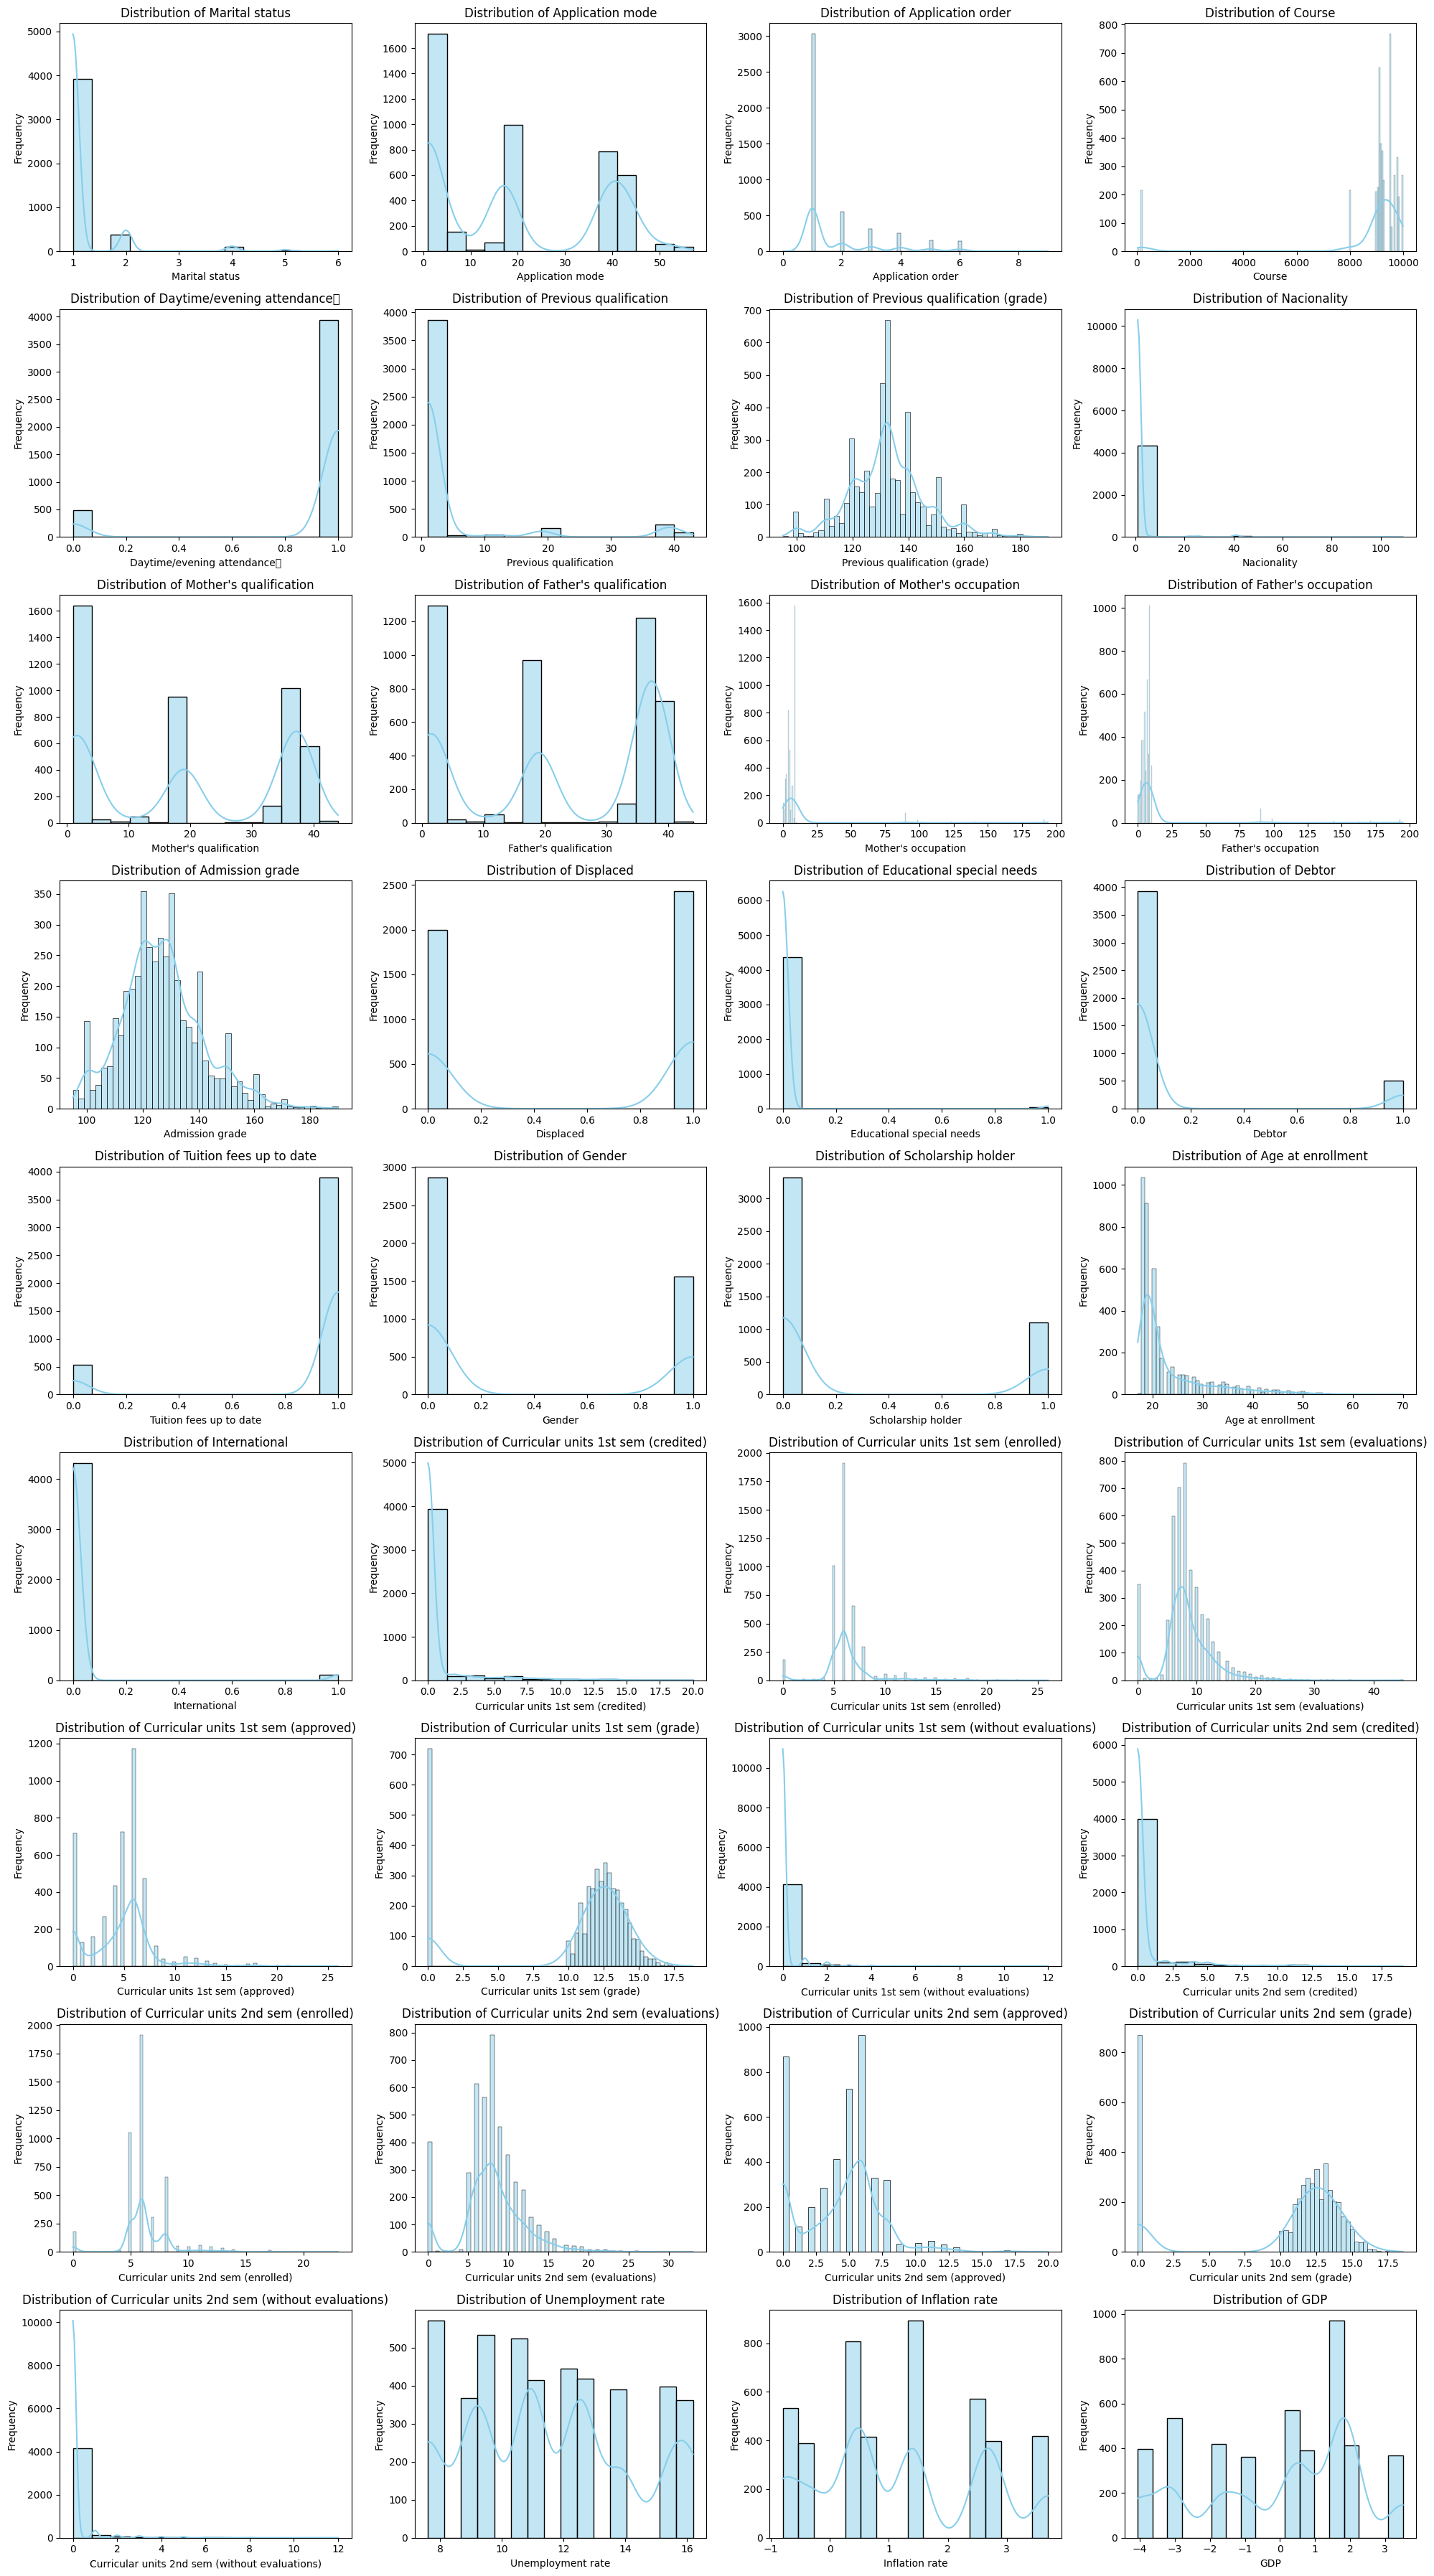

In [1036]:
# Distribusi data
n_cols = len(features)
n_rows = (n_cols + 2) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

###### _Insight of Data Distribution_:

1) Perlu diperhatikan ada beberapa kolom yang sebenarnya memiliki value kategorikal, tetapi sudah dalam format numerik, antara lain:
    - Marital status
    - Application mode
    - Course (kode Course)
    - Previous qualification
    - Nationality
    - Mother's qualification
    - Father's qualification
    - Mother's occupation
    - Father's occupation

2) Perlu diperhatikan juga ada beberapa kolom yang sebenarnya memiliki value binary, tetapi sudah dalam format numerik, antara lain:
    - Attendance
    - Displaced
    - Educational special needs
    - Debtor
    - Tuition fees up to date
    - Gender
    - Scholarship holder
    - International

C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\955607235.py:14: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ACER\.conda\envs\data-science\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


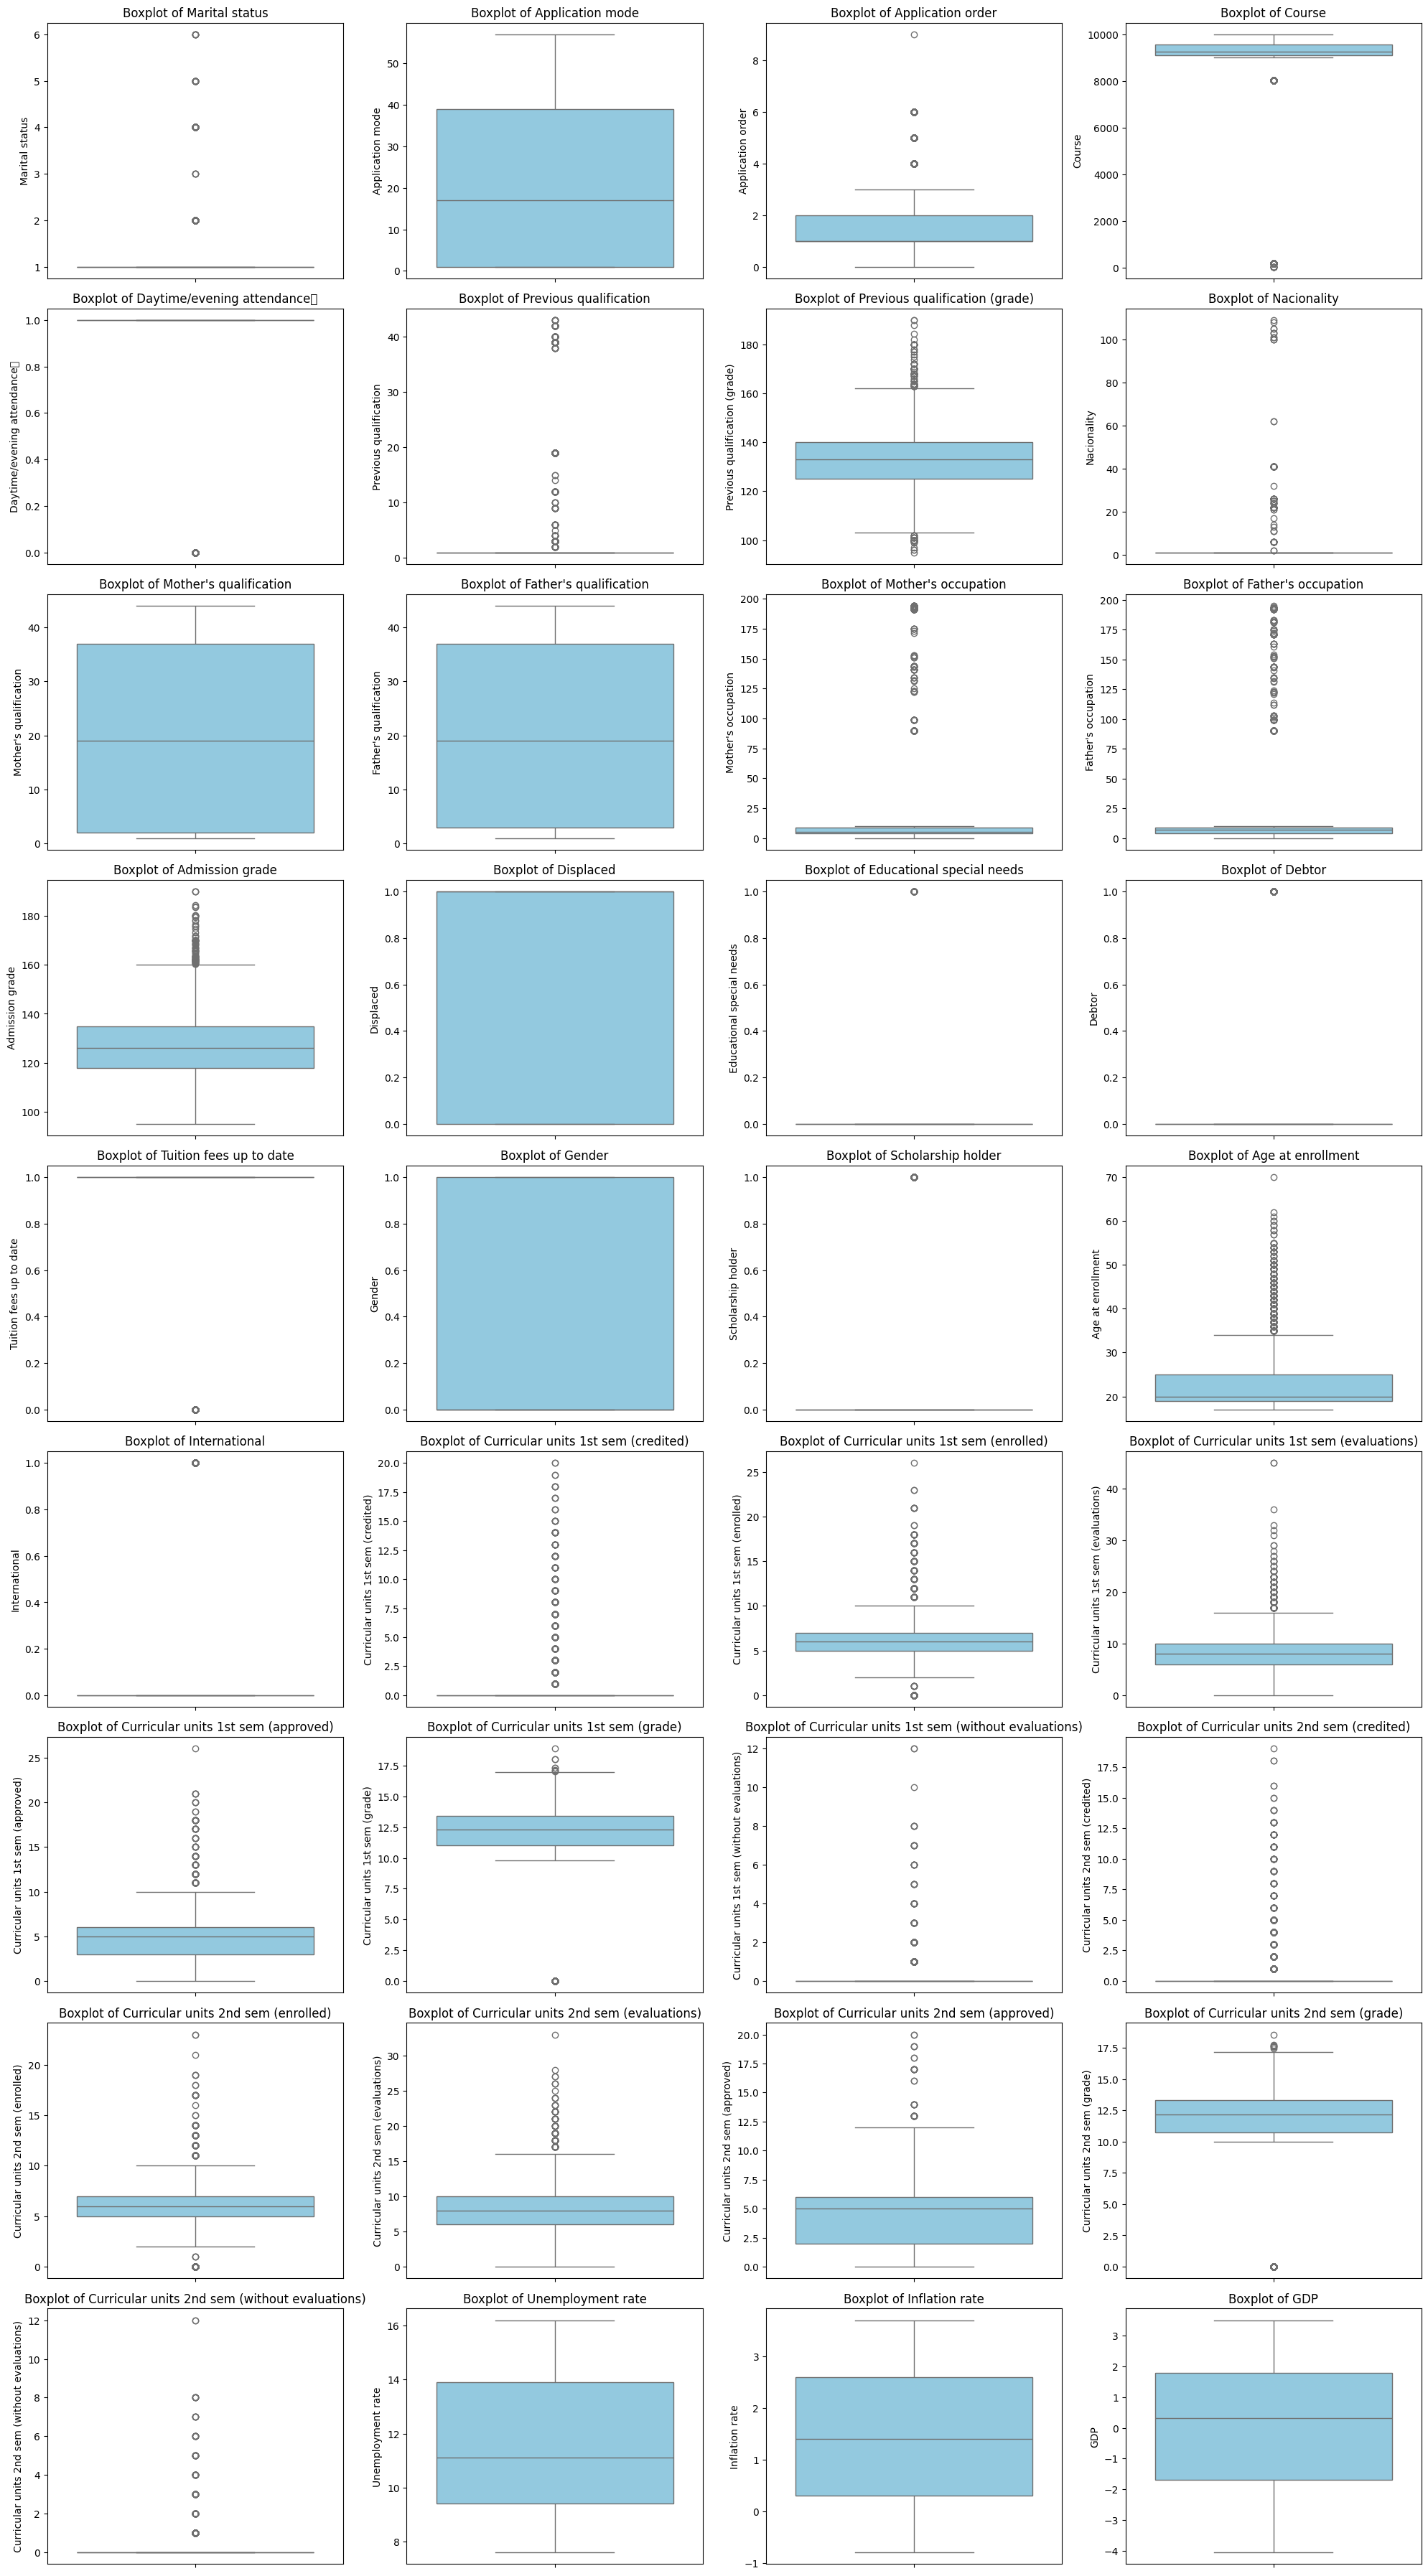

In [1037]:
# Periksa outlier
n_cols = len(features)
n_rows = (n_cols + 2) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.boxplot(data=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

###### Marital status

In [1038]:
df['Marital status'].value_counts().sort_index()

Marital status
1    3919
2     379
3       4
4      91
5      25
6       6
Name: count, dtype: int64

_Keterangan_:
- 1 = Single (Belum Menikah)
- 2 = Married (Sudah Menikah)
- 3 = Widower (Duda/Janda) - Pernikahan berakhir karena ajal
- 4 = Divorced (Sudah Cerai) - Bercerai secara hukum
- 5 = Facto Union (Hidup bersama tanpa pernikahan resmi/formal)
- 6 = Legally Separated (Hidup Terpisah)

###### Application mode

In [1039]:
df['Application mode'].value_counts().sort_index()

Application mode
1     1708
2        3
5       16
7      139
10      10
15      30
16      38
17     872
18     124
26       1
27       1
39     785
42      77
43     312
44     213
51      59
53      35
57       1
Name: count, dtype: int64

_Keterangan_:
- 1 = 1st phase - general contingent
- 2 = Ordinance No. 612/93
- 5 = 1st phase - special contingent (Azores Island)
- 7 = Holders of other higher courser
- 10 = Ordinance No. 854-B/99
- 15 = International student (bachelor)
- 16 = 1st phase - special contingent (Madeira Island)
- 17 = 2nd phase - general contingent
- 18 = 3rd phase - general contingent
- 26 = Ordinance No. 533-A/99, item b2 (Different Plan)
- 27 = Ordinance No. 533-A/99, item b3 (Other Institution)
- 39 = Over 23 years old
- 42 = Transfer
- 43 = Change of course
- 44 = Technological specialization diploma holders
- 51 = Change of institution/course
- 53 = Short/cycle diploma holders
- 57 = Change of institution/course (International)

###### Application order

In [1040]:
df['Application order'].value_counts().sort_index()

Application order
0       1
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
Name: count, dtype: int64

_Keterangan_:
- 0 = 1st choice
- 1 = 2nd choice
- 2 = 3rd choice
- 3 = 4th choice
- 4 = 5th choice
- 5 = 6th choice
- 6 = 7th choice
- 7 = 8th choice
- 8 = 9th choice
- 9 = Last choice

###### Course

In [1041]:
df['Course'].value_counts().sort_index()

Course
33       12
171     215
8014    215
9003    210
9070    226
9085    337
9119    170
9130    141
9147    380
9238    355
9254    252
9500    766
9556     86
9670    268
9773    331
9853    192
9991    268
Name: count, dtype: int64

_Keterangan_:
- 33 = Biofuel Production Technologies
- 171 = Animation and Multimedia Design
- 8014 = Social Services (evening attendance)
- 9003 = Agronomy
- 9070 = Communication Design
- 9085 = Veterinary Nursing
- 9119 = Informatics Engineering
- 9130 = Equinculture
- 9147 = Management
- 9238 = Social Service
- 9254 = Tourism
- 9500 = Nursing
- 9556 = Oral Hygiene
- 9670 = Advertising and Marketing Management
- 9773 = Journalism and Communication
- 9853 = Basic Education
- 9991 = Management (evening attendance)

###### Previous qualification

In [1042]:
df['Previous qualification'].value_counts().sort_index()

Previous qualification
1     3717
2       23
3      126
4        8
5        1
6       16
9       11
10       4
12      45
14       1
15       2
19     162
38       7
39     219
40      40
42      36
43       6
Name: count, dtype: int64

_Keterangan_:
- 1 = Secondary education
- 2 = Higher education - bachelor's degree
- 3 = Higher education - degree
- 4 = Higher education - master's
- 5 = Higher education - doctorate
- 6 = Frequency of higher education
- 9 = 12th year of schooling - not completed
- 10 = 11th year of schooling - not completed
- 12 = Other - 11th years of schooling
- 14 = 10th year of schooling
- 15 = 10th year of schooling - not completed
- 19 = Basic education 3rd cycle (9/10/11th year) or equiv
- 38 = Basic education 2nd cycle (6/7/8th year) or equiv
- 39 = Technological specialization course
- 40 = Higher education - degree (1st cycle)
- 42 = Professional higher technical course
- 43 = Higher education - master (2nd cycle)

###### Nationality

In [1043]:
df['Nacionality'].value_counts().sort_index()

Nacionality
1      4314
2         2
6        13
11        3
13        1
14        1
17        1
21        2
22       13
24        5
25        2
26       14
32        1
41       38
62        2
100       3
101       2
103       3
105       2
108       1
109       1
Name: count, dtype: int64

_Keterangan_:
- 1 = Portuguese
- 2 = German
- 6 = Spanish
- 11 = Italian
- 13 = Dutch
- 14 = English
- 17 = Lithuanian
- 21 = Angolan
- 22 = Verdean
- 24 = Guinean
- 25 = Mozambican
- 26 = Santomean
- 32 = Turkish
- 41 = Brazilian
- 62 = Romanian
- 100 = Moldova (Republic of)
- 101 = Mexican
- 103 = Ukrainian
- 108 = Cuban
- 109 = Colombian 

###### Mother's qualification

In [1044]:
df["Mother\'s qualification"].value_counts().sort_index()

Mother's qualification
1     1069
2       83
3      438
4       49
5       21
6        4
9        8
10       3
11       3
12      42
14       2
18       1
19     953
22       1
26       1
27       1
29       3
30       3
34     130
35       3
36       3
37    1009
38     562
39       8
40       9
41       6
42       4
43       4
44       1
Name: count, dtype: int64

_Keterangan_:
- 1 = Secondary education
- 2 = Higher education - bachelor's degree
- 3 = Higher education - degree
- 4 = Higher education - master's
- 5 = Higher education - doctorate
- 6 = Frequency of higher education
- 9 = 12th year of schooling - not completed
- 10 = 11th year of schooling - not completed
- 11 = 7th year (old)
- 12 = Other - 11th years of schooling
- 14 = 10th year of schooling
- 15 = 10th year of schooling - not completed
- 18 = General commerce course
- 19 = Basic education 3rd cycle (9/10/11th year) or equiv
- 22 = Technical professional course
- 26 = 7th year of schooling - not completed
- 27 = 2nd cycle of general high school course
- 29 = 9th year of schooling - not completed
- 30 = 8th year of schooling
- 34 = Unknown
- 35 = Can't read or write
- 36 = Can read without having a 4th year of schooling
- 37 = Basic education 1st cycle (4/5th year) or equiv
- 38 = Basic education 2nd cycle (6/7/8th year) or equiv
- 39 = Technological specialization course
- 40 = Higher education - degree (1st cycle)
- 41 = Specialized higher studies course
- 42 = Professional higher technical course
- 43 = Higher education - master (2nd cycle)
- 44 = Higher education - doctorate (3rd cycle)

###### Father's qualification

In [1045]:
df['Father\'s qualification'].value_counts().sort_index()

Father's qualification
1      904
2       68
3      282
4       39
5       18
6        2
9        5
10       2
11      10
12      38
13       1
14       4
18       1
19     968
20       1
22       4
25       1
26       2
27       1
29       3
30       4
31       1
33       1
34     112
35       2
36       8
37    1209
38     702
39      20
40       5
41       2
42       1
43       2
44       1
Name: count, dtype: int64

_Keterangan_:
- 1 = Secondary education
- 2 = Higher education - bachelor's degree
- 3 = Higher education - degree
- 4 = Higher education - master's
- 5 = Higher education - doctorate
- 6 = Frequency of higher education
- 9 = 12th year of schooling - not completed
- 10 = 11th year of schooling - not completed
- 11 = 7th year (old)
- 12 = Other - 11th years of schooling
- 13 = 2nd year complementary high school course
- 14 = 10th year of schooling
- 15 = 10th year of schooling - not completed
- 18 = General commerce course
- 19 = Basic education 3rd cycle (9/10/11th year) or equiv
- 20 = Complementary high school course
- 22 = Technical professional course
- 25 = Complementary high school course - not concluded
- 26 = 7th year of schooling - not completed
- 27 = 2nd cycle of general high school course
- 29 = 9th year of schooling - not completed
- 30 = 8th year of schooling
- 31 = General course of administration and commerce
- 33 = Supplementary Accounting and Administration
- 34 = Unknown
- 35 = Can't read or write
- 36 = Can read without having a 4th year of schooling
- 37 = Basic education 1st cycle (4/5th year) or equiv
- 38 = Basic education 2nd cycle (6/7/8th year) or equiv
- 39 = Technological specialization course
- 40 = Higher education - degree (1st cycle)
- 41 = Specialized higher studies course
- 42 = Professional higher technical course
- 43 = Higher education - master (2nd cycle)
- 44 = Higher education - doctorate (3rd cycle)

###### Mother's occupation

In [1046]:
df['Mother\'s occupation'].value_counts().sort_index()

Mother's occupation
0       144
1       102
2       318
3       351
4       817
5       530
6        91
7       272
8        36
9      1577
10        4
90       70
99       17
122       2
123       7
125       1
131       1
132       3
134       4
141       8
143       3
144       6
151       3
152       2
153       2
171       1
173       1
175       5
191      26
192       5
193       4
194      11
Name: count, dtype: int64

_Keterangan_:
- 0 = Student 
- 1 = Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 
- 2 = Specialists in Intellectual and Scientific Activities 
- 3 = Intermediate Level Technicians and Professions 
- 4 = Administrative staff 
- 5 = Personal Services, Security and Safety Workers and Sellers 
- 6 = Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 
- 7 = Skilled Workers in Industry, Construction and Craftsmen 
- 8 = Installation and Machine Operators and Assembly Workers 
- 9 = Unskilled Workers 
- 10 = Armed Forces Professions 
- 90 = Other Situation 
- 99 = (blank) 
- 122 = Health professionals 
- 123 = teachers 
- 125 = Specialists in information and communication technologies (ICT) 
- 131 = Intermediate level science and engineering technicians and professions 
- 132 = Technicians and professionals, of intermediate level of health 
- 134 = Intermediate level technicians from legal, social, sports, cultural and similar services 
- 141 = Office workers, secretaries in general and data processing operators 
- 143 = Data, accounting, statistical, financial services and registry-related operators 
- 144 = Other administrative support staff 
- 151 = personal service workers 
- 152 = sellers 
- 153 = Personal care workers and the like 
- 171 = Skilled construction workers and the like, except electricians 
- 173 = Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like 
- 175 = Workers in food processing, woodworking, clothing and other industries and crafts 
- 191 = cleaning workers 
- 192 = Unskilled workers in agriculture, animal production, fisheries and forestry
- 193 = Unskilled workers in extractive industry, construction, manufacturing and transport 
- 194 = Meal preparation assistants

###### Father's occupation

In [1047]:
df['Father\'s occupation'].value_counts().sort_index()

Father's occupation
0       128
1       134
2       197
3       384
4       386
5       516
6       242
7       666
8       318
9      1010
10      266
90       65
99       19
101       1
102       2
103       4
112       2
114       1
121       1
122       2
123       3
124       1
131       1
132       1
134       1
135       3
141       1
143       1
144       8
151       2
152       3
153       1
154       1
161       1
163       5
171       8
172       2
174       1
175       4
181       3
182       2
183       3
192       6
193      15
194       2
195       1
Name: count, dtype: int64

_Keterangan_:
- 0 = Student 
- 1 = Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 
- 2 = Specialists in Intellectual and Scientific Activities 
- 3 = Intermediate Level Technicians and Professions 
- 4 = Administrative staff 
- 5 = Personal Services, Security and Safety Workers and Sellers 
- 6 = Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 
- 7 = Skilled Workers in Industry, Construction and Craftsmen 
- 8 = Installation and Machine Operators and Assembly Workers 
- 9 = Unskilled Workers 
- 10 = Armed Forces Professions 
- 90 = Other Situation 
- 99 = (blank) 
- 101 = Armed Forces Officers 
- 102 = Armed Forces Sergeants 
- 103 = Other Armed Forces personnel 
- 112 = Directors of administrative and commercial services 
- 114 = Hotel, catering, trade and other services directors 
- 121 = Specialists in the physical sciences, mathematics, engineering and related techniques 
- 122 = Health professionals 
- 123 = teachers 
- 124 = Specialists in finance, accounting, administrative organization, public and commercial relations 
- 131 = Intermediate level science and engineering technicians and professions 
- 132 = Technicians and professionals, of intermediate level of health 
- 134 = Intermediate level technicians from legal, social, sports, cultural and similar services 
- 135 = Information and communication technology technicians 
- 141 = Office workers, secretaries in general and data processing operators 
- 143 = Data, accounting, statistical, financial services and registry-related operators 
- 144 = Other administrative support staff 
- 151 = personal service workers 
- 152 = sellers 
- 153 = Personal care workers and the like 
- 154 = Protection and security services personnel 
- 161 = Market-oriented farmers and skilled agricultural and animal production workers 
- 163 = Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence 
- 171 = Skilled construction workers and the like, except electricians 
- 172 = Skilled workers in metallurgy, metalworking and similar 
- 174 = Skilled workers in electricity and electronics 
- 175 = Workers in food processing, woodworking, clothing and other industries and crafts 
- 181 = Fixed plant and machine operators 
- 182 = assembly workers 
- 183 = Vehicle drivers and mobile equipment operators 
- 192 = Unskilled workers in agriculture, animal production, fisheries and forestry 
- 193 = Unskilled workers in extractive industry, construction, manufacturing and transport 
- 194 = Meal preparation assistants 
- 195 = Street vendors (except food) and street service providers

##### Kolom Target

In [1048]:
target = df.columns[-1]

C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\4062630300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target, palette='Set1')


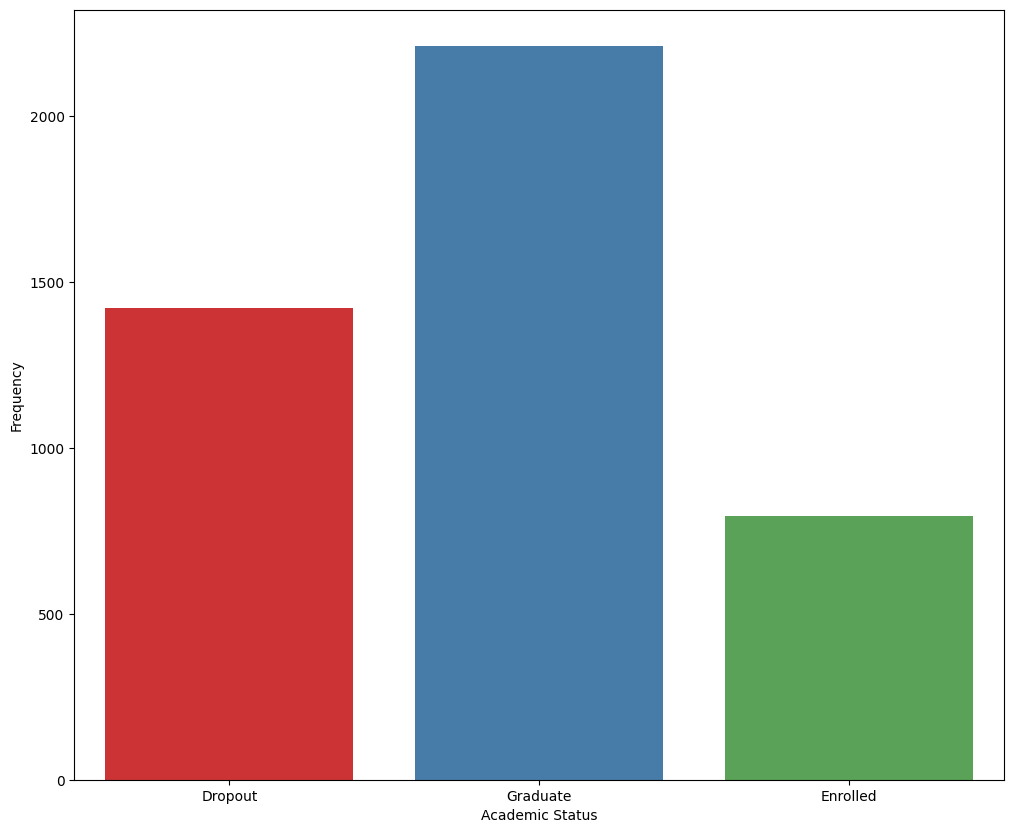

In [1049]:
plt.figure(figsize=(12, 10))
sns.countplot(data=df, x=target, palette='Set1')
plt.title('')
plt.xlabel('Academic Status')
plt.ylabel('Frequency')
plt.show()

#### Cek Hubungan antar Data

##### Debtor vs Target

In [1050]:
# Debtor
df['Debtor'].value_counts()

Debtor
0    3921
1     503
Name: count, dtype: int64

In [1051]:
debtor_df = df.groupby('Debtor')['Target'].value_counts().unstack(fill_value=0)

debtor_df

Target,Dropout,Enrolled,Graduate
Debtor,,,
0,1109,704,2108
1,312,90,101


In [1052]:
debtor_df['Total'] = debtor_df.sum(axis=1)

debtor_df

Target,Dropout,Enrolled,Graduate,Total
Debtor,,,,
0,1109,704,2108,3921
1,312,90,101,503


In [1053]:
# Kontribusi Debtor terhadap Dropout
print(f"Percent Dropout is Debtor: {debtor_df['Dropout'].loc[1] / debtor_df['Dropout'].sum() * 100:.2f}%")

# Kontribusi Non-Debtor terhadap Dropout
print(f"Percent Dropout is Non-Debtor: {debtor_df['Dropout'].loc[0] / debtor_df['Dropout'].sum() * 100:.2f}%")

Percent Dropout is Debtor: 21.96%
Percent Dropout is Non-Debtor: 78.04%


_Isnight_:
* Dari semua mahasiswa yang dropout (1421 orang), sebanyak 21,96% (312 orang) adalah mahasiswa yang memiliki tunggakan (Debtor).
* Dapat diartikan bahwa sekitar 1 dari 5 mahasiswa yang dropout berasal dari kelompok yang punya masalah finansial.
* Meskipun begitu, mahasiswa Dropout masih didominasi oleh non-Debtor (78,04%). Artinya ada faktor lain yang lebih kuat yang dapat menyebabkan Dropout.

In [1054]:
# Tingkat risiko Dropout pada Debtor
print(f"Percent Debtor is dropout: {debtor_df['Dropout'].loc[1] / debtor_df['Total'].loc[1].sum() * 100:.2f}%")

# Tingkat risiko Dropout pada Non-Debtor
print(f"Percent Non-Debtor is dropout: {debtor_df['Dropout'].loc[0] / debtor_df['Total'].loc[0].sum() * 100:.2f}%")

Percent Debtor is dropout: 62.03%
Percent Non-Debtor is dropout: 28.28%


_Isnight_:
* Dari semua mahasiswa yang memiliki tunggakan (503 orang), sebanyak 62,03% (312 orang) akhirnya Dropout.
* Mahasiswa dengan status Debtor memiliki risiko dropout 2x lebih tinggi dibandingkan dengan mahasiswa non-Debtor.

In [1055]:
# Proporsi Debtor + Dropout
print(f"Percent Debtor & Dropout: {debtor_df.loc[1, 'Dropout'] / debtor_df['Total'].sum() * 100:.2f}%") 

# Proporsi Non-Debtor + Dropout
print(f"Percent Non-Debtor & Dropout: {debtor_df.loc[0, 'Dropout'] / debtor_df['Total'].sum() * 100:.2f}%") 

Percent Debtor & Dropout: 7.05%
Percent Non-Debtor & Dropout: 25.07%


_Insight_:
* Dari total populasi (4424 mahasiswa), sebanyak 7,05% (312 orang) berstatus Debtor dan akhirnya mengalami Dropout.
* Artinya sebanyak 7% sampel dari seluruh populasi dapat menjadi contoh kasus gagal lulus akibat masalah finansial.

##### Tuition fees up to date vs Target

In [1056]:
# Tuition fees up to date
df['Tuition fees up to date'].value_counts()

Tuition fees up to date
1    3896
0     528
Name: count, dtype: int64

In [1057]:
payment_df = df.groupby('Tuition fees up to date')['Target'].value_counts().unstack(fill_value=0)

payment_df

Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,457,42,29
1,964,752,2180


In [1058]:
payment_df['Total'] = payment_df.sum(axis=1)

payment_df

Target,Dropout,Enrolled,Graduate,Total
Tuition fees up to date,,,,
0,457,42,29,528
1,964,752,2180,3896


In [1059]:
# Pengaruh Ketidaktepatan pembayaran terhadap Dropout
print(f"Percent Dropout is Paid-Lately: {payment_df['Dropout'].loc[0] / payment_df['Dropout'].sum() * 100:.2f}%")
print(f"Percent Dropout is On-Time: {payment_df['Dropout'].loc[1] / payment_df['Dropout'].sum() * 100:.2f}%")

Percent Dropout is Paid-Lately: 32.16%
Percent Dropout is On-Time: 67.84%


_Insight_:
* Sebanyak 32,16% mahasiswa yang Dropout memiliki riwayat telat bayar.

In [1060]:
# Tingkat risiko Dropout pada mahasiswa yang terlambat bayar
print(f"Percent Paid-Lately is dropout: {payment_df['Dropout'].loc[0] / payment_df['Total'].loc[0].sum() * 100:.2f}%")

# Tingkat risiko Dropout pada mahasiswa yang bayar tepat waktu
print(f"Percent On-Time is dropout: {payment_df['Dropout'].loc[1] / payment_df['Total'].loc[1].sum() * 100:.2f}%")

Percent Paid-Lately is dropout: 86.55%
Percent On-Time is dropout: 24.74%


_Insight_:
* Mahasiswa yang memiliki riwayat telat bayar memiliki risiko Dropout 3.5 kali lebih tinggi.

In [1061]:
# Proporsi Paid-Lately + Dropout
print(f"Percent Paid-Lately & Dropout: {payment_df.loc[0, 'Dropout'] / payment_df['Total'].sum() * 100:.2f}%") 

# Proporsi On-Time + Dropout
print(f"Percent On-Time & Dropout: {payment_df.loc[1, 'Dropout'] / payment_df['Total'].sum() * 100:.2f}%") 

Percent Paid-Lately & Dropout: 10.33%
Percent On-Time & Dropout: 21.79%


_Insight_:
* Dari total populasi mahasiswa, sebanyak 10,33% memiliki riwayat telat bayar dan akhirnya mengalami dropout. Namun, proporsi tersebut masih lebih kecil dibanding dengan jumlah mahasiswa dropout yang tidak memiliki riwayat telat bayar (21,79%).
* Hal ini menandakan bahwa ada faktor lain yang memiliki pengaruh lebih kuat terhadap Dropout daripada waktu pembayaran tagihan pendidikan.

##### Scholarship holder vs Target

In [1062]:
# Scholarship holder
df['Scholarship holder'].value_counts()

Scholarship holder
0    3325
1    1099
Name: count, dtype: int64

In [1063]:
scholarship_df = df.groupby('Scholarship holder')['Target'].value_counts().unstack(fill_value=0)

scholarship_df

Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,1287,664,1374
1,134,130,835


In [1064]:
scholarship_df['Total'] = scholarship_df.sum(axis=1)

scholarship_df

Target,Dropout,Enrolled,Graduate,Total
Scholarship holder,,,,
0,1287,664,1374,3325
1,134,130,835,1099


In [1065]:
# Efektifitas program Scholarship terhadap Dropout
print(f"Percent Dropout is Non-Scholarship holder: {scholarship_df['Dropout'].loc[0] / scholarship_df['Dropout'].sum() * 100:.2f}%")
print(f"Percent Dropout is Scholarship holder: {scholarship_df['Dropout'].loc[1] / scholarship_df['Dropout'].sum() * 100:.2f}%")

Percent Dropout is Non-Scholarship holder: 90.57%
Percent Dropout is Scholarship holder: 9.43%


_Insight_:
* Program scholarship dapat dikatakan efektif karena terbukti mampu menekan angka Dropout mahasiswa (hanya 1 dari 10 Scholarship holder yang mengalami Dropout).

In [1066]:
# Tingkat risiko Dropout pada mahasiswa yang bukan scholarship holder
print(f"Percent Non-Scholarship holder is dropout: {scholarship_df['Dropout'].loc[0] / scholarship_df['Total'].loc[0].sum() * 100:.2f}%")

# Tingkat risiko Dropout pada mahasiswa yang scholarship holder
print(f"Percent Scholarship holder is dropout: {scholarship_df['Dropout'].loc[1] / scholarship_df['Total'].loc[1].sum() * 100:.2f}%")

Percent Non-Scholarship holder is dropout: 38.71%
Percent Scholarship holder is dropout: 12.19%


_Insight_:
* Non-Scholarship holder memiliki tingkat risiko Dropout 3x lebih besar dibanding scholarship holder.

In [1067]:
# Proporsi Non-Scholarship holder + Dropout
print(f"Percent Non-Scholarship holder & Dropout: {scholarship_df.loc[0, 'Dropout'] / scholarship_df['Total'].sum() * 100:.2f}%")

# Proporsi Scholarship holder + Dropout
print(f"Percent Scholarship holder & Dropout: {scholarship_df.loc[1, 'Dropout'] / scholarship_df['Total'].sum() * 100:.2f}%")

Percent Non-Scholarship holder & Dropout: 29.09%
Percent Scholarship holder & Dropout: 3.03%


_Insight_:
* Dari total populasi, sebanyak 29,09% mahasiswa merupakan Non-Scholarship holder yang akhirnya mengalami dropout.

##### GDP vs Target 

In [1068]:
df['GDP'].describe()

count    4424.000000
mean        0.001969
std         2.269935
min        -4.060000
25%        -1.700000
50%         0.320000
75%         1.790000
max         3.510000
Name: GDP, dtype: float64

_Insight_:
* Nilai GDP berkisar antara -4.06 - 3.51. Sepertinya ini GDP yang sudah distandarisasi (z-score). 
* Diketahui rata-ratanya ~ 0, maka jika negatif dapat bermakna nilai GDP di bawah rata-rata, sedangkan positif di atas rata-rata.

In [1069]:
df['GDP'].nunique()

10

In [1070]:
gdp_df = df.groupby('Target')['GDP'].agg([
    'count',
    'min',
    'median',
    'max',
    'mean',
    'std'
]).round(2)

gdp_df

,count,min,median,max,mean,std
Target,,,,,,
Dropout,1421,-4.06,0.32,3.51,-0.15,2.25
Enrolled,794,-4.06,0.32,3.51,0.05,2.32
Graduate,2209,-4.06,0.79,3.51,0.08,2.26


_Insight_:
* Mahasiswa yang dropout cenderung berasal dari periode/konteks dengan GDP di bawah rata-rata (-0.15 std).
* Mahasiswa yang lulus cenderung berasal dari konteks GDP di atas rata-rata (+0.08 std).
* Selisih mean Dropout vs Graduate = 0.23 std yang artinya GDP memiliki efek kecil tetapi konsisten.
* Jika dilihat berdasarkan nilai range dan std, ketiganya memiliki sebaran GDP yang hampir sama. Maka, GDP hanya dapat dijadikan sebagai faktor kontekstual yang memperkuat/memperlemah faktor lain. 

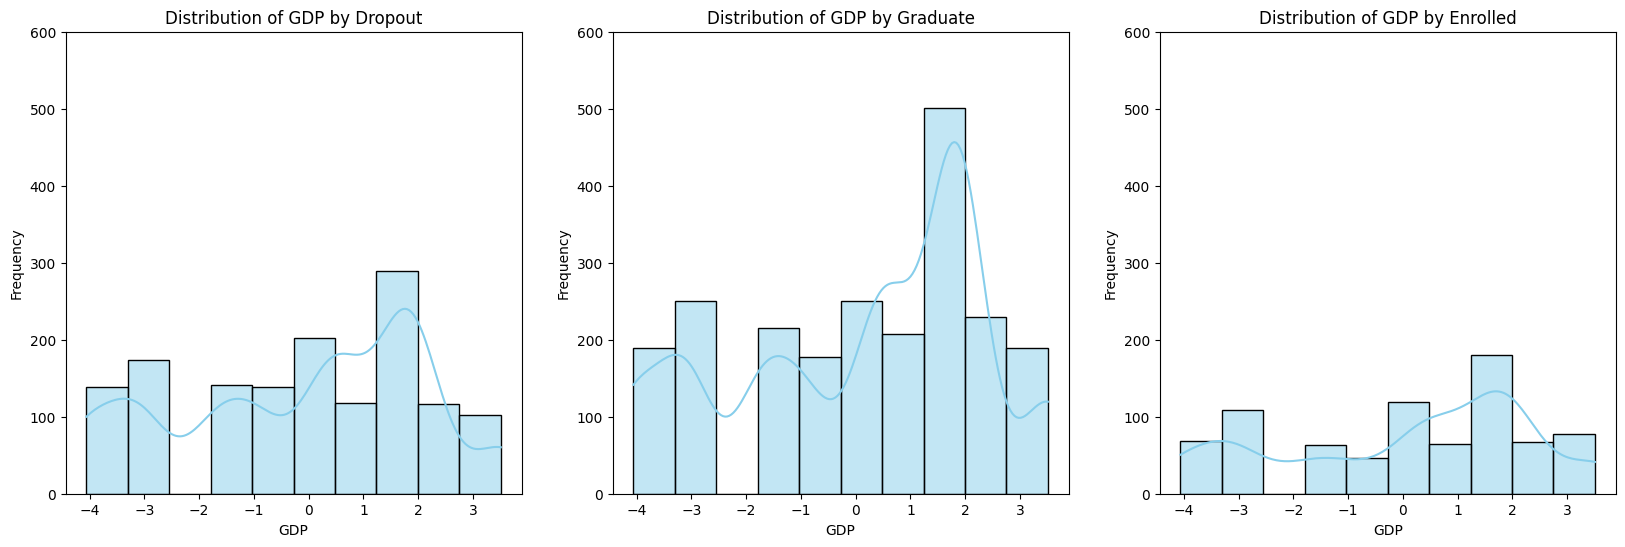

In [1071]:
# PLot histogram GDP by Target
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, target in enumerate(df['Target'].unique()):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[df['Target'] == target]['GDP'], bins=10, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of GDP by {target}')
    axes[i].set_xlabel('GDP')
    axes[i].set_ylabel('Frequency')
    axes[i].set_ylim(0, 600)
plt.show()

_Insight_:
* Meskipun grafik menujukkan bahwa data mencatat kelulusan mahasiswa banyak terjadi dalam kondisi ekonomi yang baik, sepertinya GDP tidak memiliki pengaruh cukup kuat terhadap status Dropout mahasiswa karena jika dilihat dari grafik, frequency Dropout pada periode dimana GDP negatif cenderung tidak jauh berbeda saat GDP positif.

##### GDP vs Debtor

C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\3334280416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Debtor', y='GDP', palette='Set2')


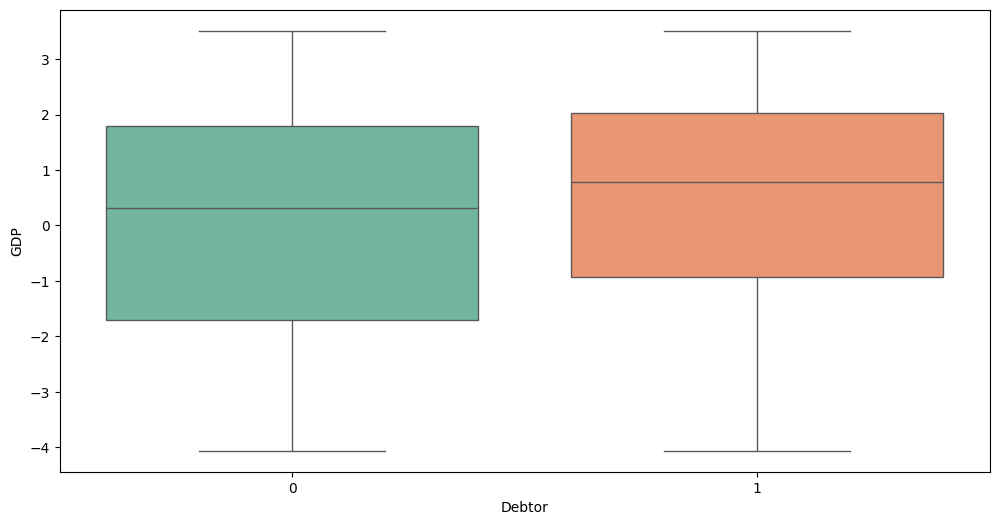

In [1072]:
# Hubungan GDP terhadap Debtor
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Debtor', y='GDP', palette='Set2')
plt.show()

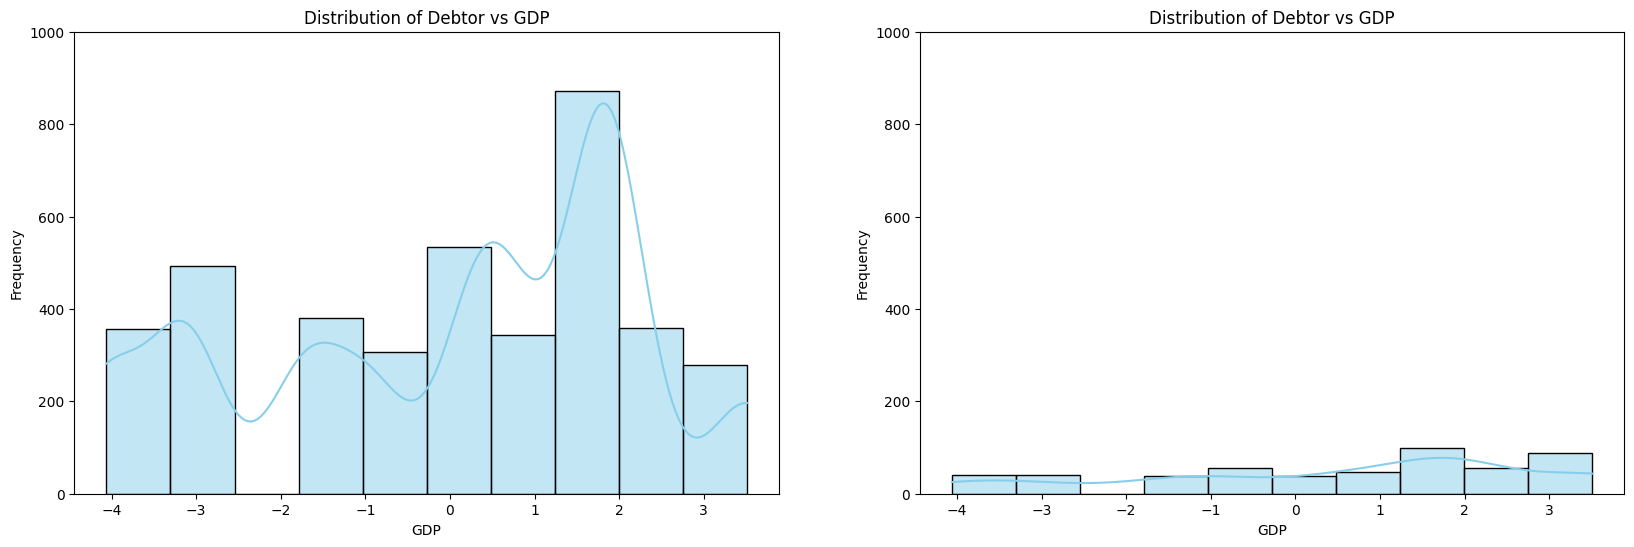

In [1073]:
# PLot histogram GDP vs Debtor
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for i, debt in enumerate(df['Debtor'].unique()):
    plt.subplot(1, 2, i + 1)
    sns.histplot(df[df['Debtor'] == debt]['GDP'], bins=10, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of Debtor vs GDP')
    axes[i].set_xlabel('GDP')
    axes[i].set_ylabel('Frequency')
    axes[i].set_ylim(0, 1000)
plt.show()

_Insight_:
* Tingkat GDP tidak menjadi faktor pendorong yang cukup kuat terhadap keputusan mahasiswa untuk menjadi Debtor.
* Saat GDP tinggi, jumlah Debtor justru sedikit lebih banyak daripada saat GDP rendah. 

##### Inflation rate vs Target

In [1074]:
df['Inflation rate'].describe().round(2)

count    4424.00
mean        1.23
std         1.38
min        -0.80
25%         0.30
50%         1.40
75%         2.60
max         3.70
Name: Inflation rate, dtype: float64

In [1075]:
inlfaton_df = df.groupby('Target')['Inflation rate'].agg([
    'count',
    'min',
    'median',
    'max',
    'mean',
    'std'
]).round(2)

inlfaton_df

,count,min,median,max,mean,std
Target,,,,,,
Dropout,1421,-0.8,1.4,3.7,1.28,1.40
Enrolled,794,-0.8,1.4,3.7,1.21,1.37
Graduate,2209,-0.8,0.6,3.7,1.20,1.37


_Insight_:
* Data justru mencatat Dropout sedikit lebih banyak terjadi saat inflation rate rendah (Mean < Median). Sementara itu, saat inflation rate tinggi, banyak mahasiswa yang Graduate (Mean > Median).
* Jika dilihat berdasarkan nilai range dan std, ketiganya memiliki sebaran Inflation rate yang hampir sama. Maka, Inflation rate hanya dapat dijadikan sebagai faktor kontekstual yang memperkuat/memperlemah faktor lain. 

C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\2747999074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='Inflation rate', palette='Set1')


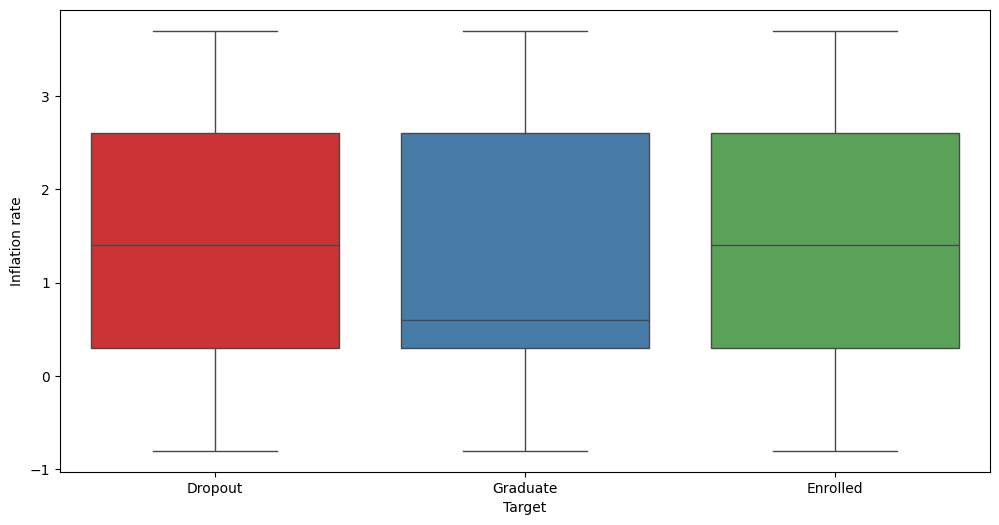

In [1076]:
# Inflation rate vs Target
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Target', y='Inflation rate', palette='Set1')
plt.show()

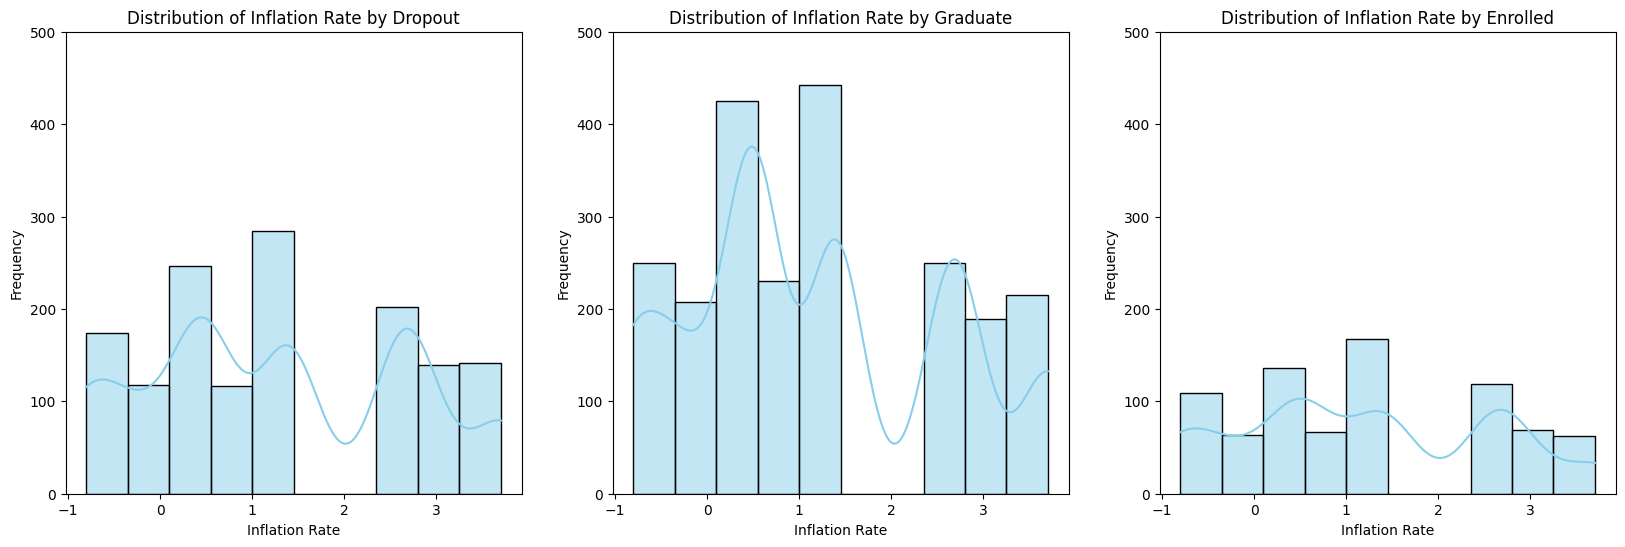

In [1077]:
# PLot histogram Inflation rate by Target
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, target in enumerate(df['Target'].unique()):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[df['Target'] == target]['Inflation rate'], bins=10, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of Inflation Rate by {target}')
    axes[i].set_xlabel('Inflation Rate')
    axes[i].set_ylabel('Frequency')
    axes[i].set_ylim(0, 500)
plt.show()

_Insight_:
* Grafik menujukkan bahwa tidak ada perbedaan signifikan antara jumlah Dropout saat inlfation rate rendah maupun tinggi. 
* Sementara, tercatat bahwa kelulusan mahasiswa lebih banyak terjadi saat inflation rate tinggi (> 1%) dibanding saat inflation rate rendah (< 1%).
* Oleh karena itu, Inflation rate tidak memiliki pengaruh cukup kuat terhadap status Dropout mahasiswa. Justru Inflation rate yang tinggi berpotensi memengaruhi psikologis mahasiswa untuk cepat lulus sehingga dapat segera mencari pekerjaan/income untuk memenuhi kebutuhan finansial yang meningkat akibat dorongan inflasi. 

##### Inflation rate vs Debtor 

C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\1555381905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Debtor', y='Inflation rate', palette='Set2')


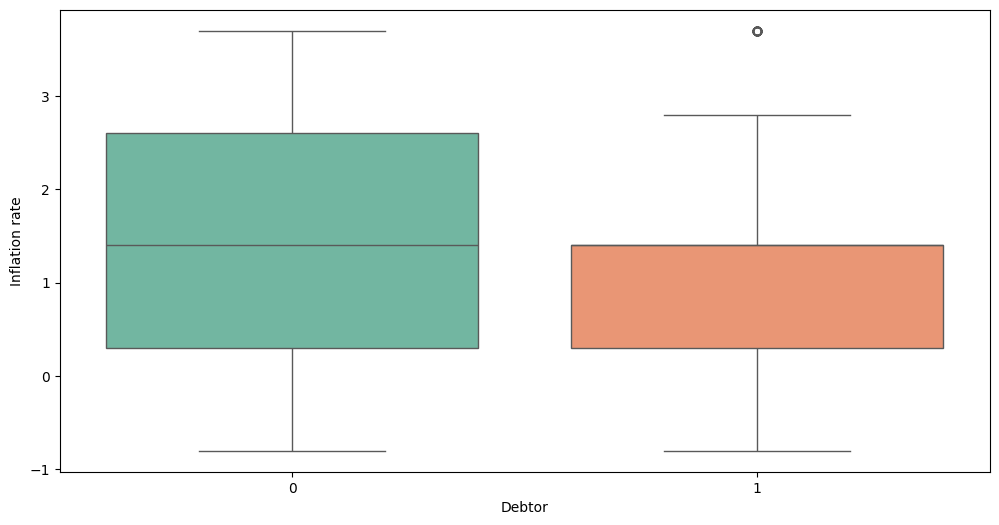

In [1078]:
# Hubungan Inflation terhadap Debtor
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Debtor', y='Inflation rate', palette='Set2')
plt.show()

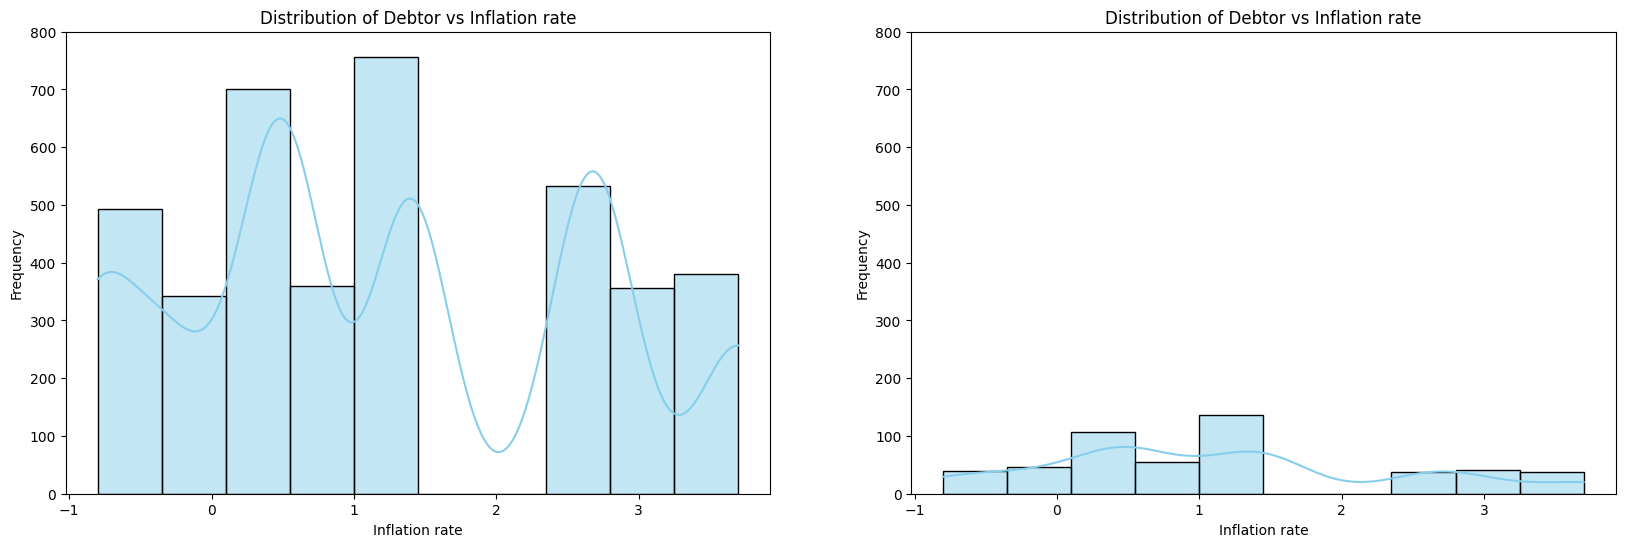

In [1079]:
# PLot histogram Inflation rate vs Debtor
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for i, debt in enumerate(df['Debtor'].unique()):
    plt.subplot(1, 2, i + 1)
    sns.histplot(df[df['Debtor'] == debt]['Inflation rate'], bins=10, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of Debtor vs Inflation rate')
    axes[i].set_xlabel('Inflation rate')
    axes[i].set_ylabel('Frequency')
    axes[i].set_ylim(0, 800)
plt.show()

_Insight_:
* Tingkat inflasi tidak menjadi faktor pendorong yang cukup kuat terhadap keputusan mahasiswa untuk menjadi Debtor.
* Saat inflasi rendah, jumlah Debtor justru sedikit lebih banyak daripada saat inflasi tinggi. 

##### Unemployment rate vs Target 

In [1080]:
df['Unemployment rate'].describe().round(2)

count    4424.00
mean       11.57
std         2.66
min         7.60
25%         9.40
50%        11.10
75%        13.90
max        16.20
Name: Unemployment rate, dtype: float64

In [1081]:
unemployment_df = df.groupby('Target')['Unemployment rate'].agg([
    'count',
    'min',
    'median',
    'max',
    'mean',
    'std'
]).round(2)

unemployment_df

,count,min,median,max,mean,std
Target,,,,,,
Dropout,1421,7.6,11.1,16.2,11.62,2.77
Enrolled,794,7.6,11.1,16.2,11.27,2.63
Graduate,2209,7.6,11.1,16.2,11.64,2.60


C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\1395526973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='Unemployment rate', palette='Set1')


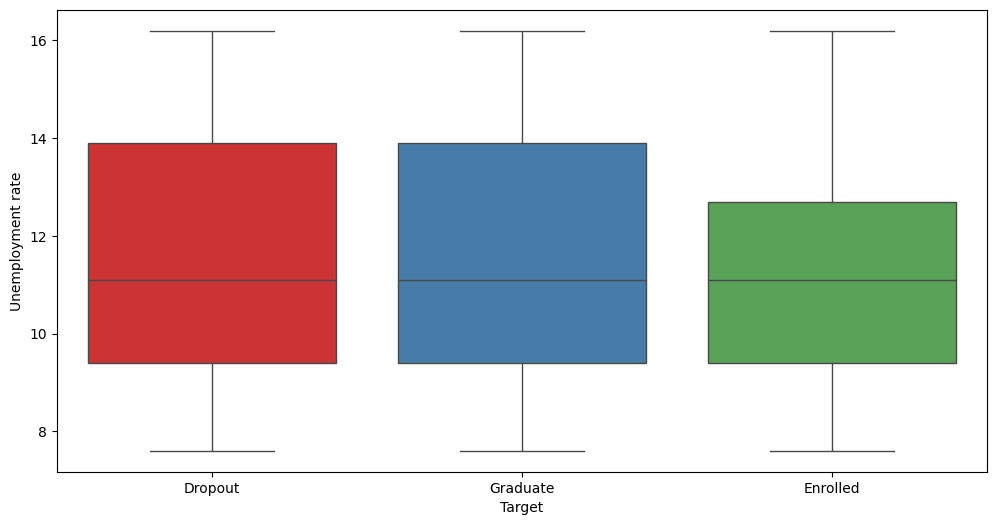

In [1082]:
# Unemployment rate vs Target
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Target', y='Unemployment rate', palette='Set1')
plt.show()

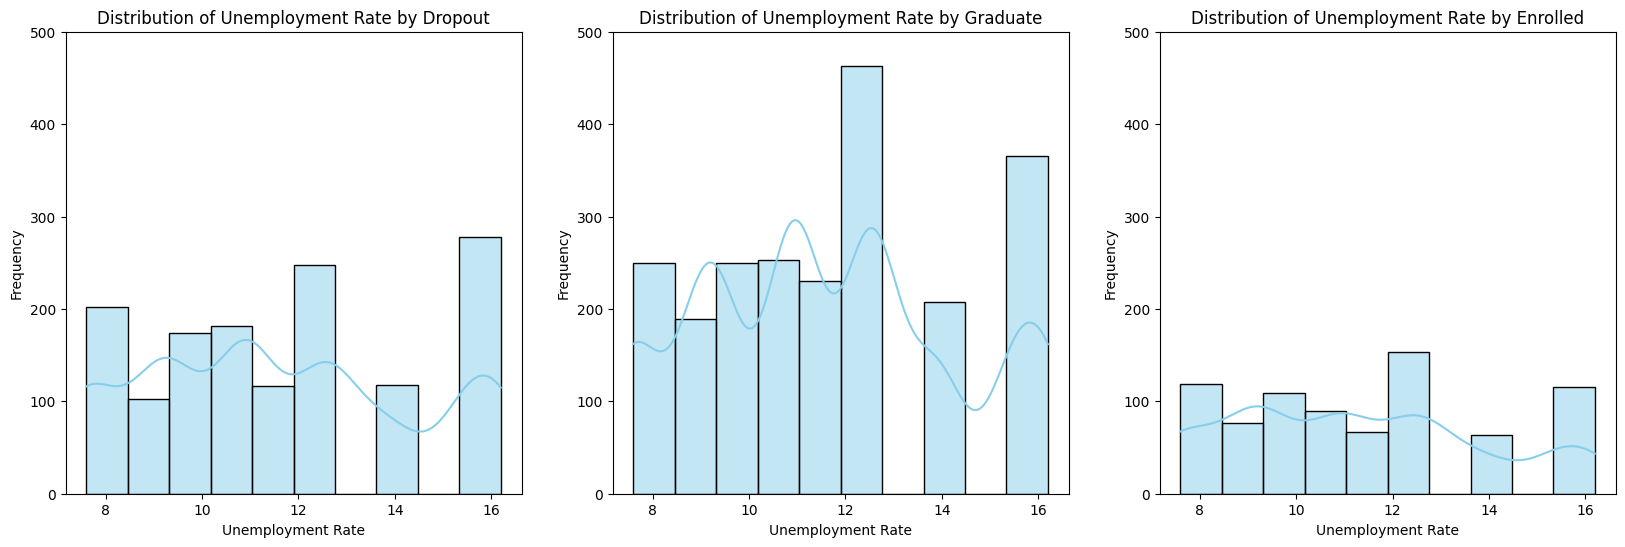

In [1083]:
# PLot histogram Unemployment rate by Target
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, target in enumerate(df['Target'].unique()):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[df['Target'] == target]['Unemployment rate'], bins=10, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of Unemployment Rate by {target}')
    axes[i].set_xlabel('Unemployment Rate')
    axes[i].set_ylabel('Frequency')
    axes[i].set_ylim(0, 500)
plt.show()

##### Unemployment rate vs Debtor 

C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\1740111194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Debtor', y='Unemployment rate', palette='Set2')


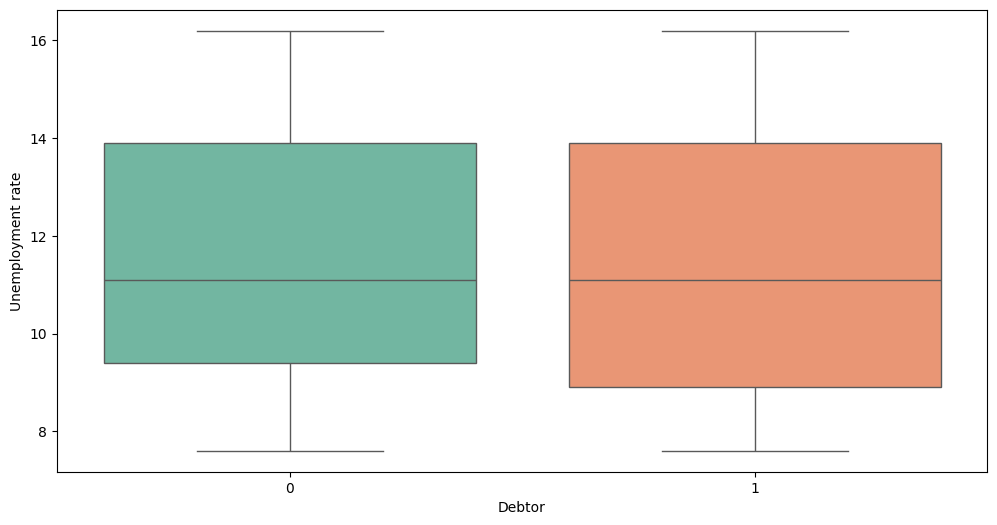

In [1084]:
# Hubungan Unemployment rate terhadap Debtor
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Debtor', y='Unemployment rate', palette='Set2')
plt.show()

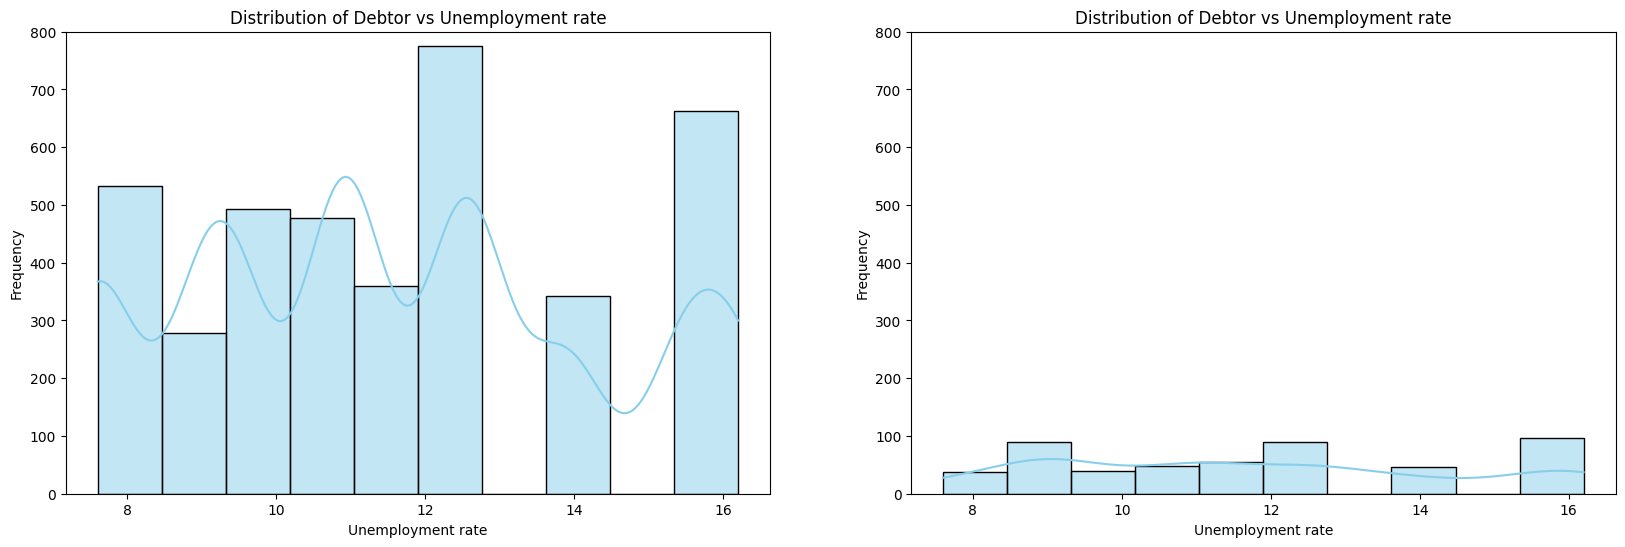

In [1085]:
# PLot histogram Unemployment rate vs Debtor
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for i, debt in enumerate(df['Debtor'].unique()):
    plt.subplot(1, 2, i + 1)
    sns.histplot(df[df['Debtor'] == debt]['Unemployment rate'], bins=10, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of Debtor vs Unemployment rate')
    axes[i].set_xlabel('Unemployment rate')
    axes[i].set_ylabel('Frequency')
    axes[i].set_ylim(0, 800)
plt.show()

_Insight_:
* Unemployment rate tidak menjadi faktor pendorong yang cukup kuat terhadap keputusan mahasiswa untuk menjadi Debtor. Dapat dilihat frequency Debtor cenderung sama rata bagaimanapun kondisi Unemployment rate-nya.

##### Grade Average sem 1 vs Target

In [1086]:
df['Curricular units 1st sem (grade)'].describe().round(2)

count    4424.00
mean       10.64
std         4.84
min         0.00
25%        11.00
50%        12.29
75%        13.40
max        18.88
Name: Curricular units 1st sem (grade), dtype: float64

In [1087]:
sem1_df = df.groupby('Target')['Curricular units 1st sem (grade)'].agg([
    'count',
    'min',
    'median',
    'max',
    'mean',
    'std'
]).round(2)

sem1_df

,count,min,median,max,mean,std
Target,,,,,,
Dropout,1421,0.0,10.93,18.00,7.26,6.03
Enrolled,794,0.0,12.00,17.00,11.13,3.68
Graduate,2209,0.0,13.00,18.88,12.64,2.70


_Insight_:
* Rata-rata nilai mahasiswa yang Dropout memang hampir 1/2 kali lebih rendah daripada rata-rata nilai mahasiswa Graduate.
* Namun jika dicermati lagi, nilai maksimum pada kelompok Dropout mencapai 18.00 (nilai sempurnanya adalah 20). Maka, mahasiswa dengan nilai sem 1 yang tinggi sekalipun masih punya risiko Dropout.

##### Grade Average sem 2 vs Target

In [1088]:
df['Curricular units 2nd sem (grade)'].describe().round(2)

count    4424.00
mean       10.23
std         5.21
min         0.00
25%        10.75
50%        12.20
75%        13.33
max        18.57
Name: Curricular units 2nd sem (grade), dtype: float64

In [1089]:
sem2_df = df.groupby('Target')['Curricular units 2nd sem (grade)'].agg([
    'count',
    'min',
    'median',
    'max',
    'mean',
    'std'
]).round(2)

sem2_df

,count,min,median,max,mean,std
Target,,,,,,
Dropout,1421,0.0,0.0,17.71,5.90,6.12
Enrolled,794,0.0,12.0,17.60,11.12,3.60
Graduate,2209,0.0,13.0,18.57,12.70,2.69


_Insight_:
* Rata-rata nilai pada mahasiswa kelompok Dropout di sem 2 cenderung menurun dibandingkan rata-rata nilai sem 1. Artinya, mahasiswa yang mengalami penurunan nilai akademik, memiliki risiko Dropout yang lebih besar.
* Tidak jauh berbeda dengan statistik nilai sem 1. Nilai maksimum sem 2 pada kelompok Dropout sebesar 17.71 (nilai sempurnanya adalah 20). Maka, mahasiswa dengan nilai sem 2 yang tinggi/di atas rata-rata sekalipun masih punya risiko Dropout. Artinya, ada kemungkinan Dropout juga dipengaruhi oleh faktor non-akademik.

## Data Preparation / Preprocessing

### Tambahkan Kolom ID (Untuk kebutuhan Dashboard)

In [1090]:
# Buat kolom Student ID sebagai primary key
def create_id(df, start_number=1, digits=4):
    df_with_id = df.copy()
    n_rows = len(df_with_id)
    
    sequential_ids = range(start_number, start_number + n_rows)
    
    # Format menjadi string dengan leading zero (misal: 0001, 0002)
    df_with_id['Student ID'] = [str(x).zfill(digits) for x in sequential_ids]
    
    return df_with_id

In [1091]:

df_with_id = create_id(df, start_number=1, digits=4)

In [1092]:
df_with_id.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [1093]:
df_with_id.tail()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Student ID
4419,1,1,6,9773,1,1,125.0,1,1,1,...,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate,4420
4420,1,1,2,9773,1,1,120.0,105,1,1,...,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout,4421
4421,1,1,1,9500,1,1,154.0,1,37,37,...,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout,4422
4422,1,1,1,9147,1,1,180.0,1,37,37,...,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate,4423
4423,1,10,1,9773,1,1,152.0,22,38,37,...,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate,4424


### Perbaikan Nama Kolom

In [1094]:
df_with_id.rename(columns={'Daytime/evening attendance\t': 'Attendance', 'Nacionality': 'Nationality'}, inplace=True)

df_with_id.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Attendance                                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

### Missing Value Handling (if any)

In [1095]:
# Kolom yang bila missing nilainya akan sulit diimputasi (misalnya kolom id, nama, target, dll)
group_1_cols = ['Student ID', 'Target']

# Kolom yang bila missing niliainya dapat diimputasi dengan nilai median
group_2_cols = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

# Kolom yang bila missing nilainya dapat diimputasi dengan nilai modus
group_3_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course', 'Attendance', 
    'Previous qualification', 'Nationality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

In [1096]:
def missing_values_handling(df):
    try:
        for col in group_1_cols:
            if df[col].isnull().any():
                df.dropna(subset=[col], inplace=True)
            else:
                pass
        for col in group_2_cols:
            if df[col].isnull().any():
                df[col].fillna(df[col].median(), inplace=True)
            else:
                pass
        for col in group_3_cols:
            if df[col].isnull().any():
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                pass

    except Exception as e:
        print(f'Error saat proses missing values handling: {e}')

In [1097]:
missing_values_handling(df_with_id)

### Duplicates Handling (if any)

In [1098]:
if df_with_id.duplicated().any():
    df_with_id.drop_duplicates(inplace=True)
else:
    print('Tidak ada duplicate values')

Tidak ada duplicate values


### Transform Data ke Tipe Asli (untuk kebutuhan Dashboard)

In [1099]:
# Kolom Kategorikal: Nominal
cat_cols = [
    'Marital status', 'Application mode',
    'Previous qualification', 'Course', 'Nationality', 
    'Mother\'s qualification', 'Father\'s qualification', 
    'Mother\'s occupation', 'Father\'s occupation', 
]

# Kolom Kategorikal: Binary
binary_cols = [
    'Attendance', 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

#### Marital status

In [1100]:
marital_mapping = {
    1: 'Single',
    2: 'Married',
    3: 'Widower',
    4: 'Divorced',
    5: 'Facto Union',
    6: 'Legally Separated'
}

ori_df = df_with_id.copy()

ori_df['Marital status'] = ori_df['Marital status'].map(marital_mapping)

ori_df['Marital status'].value_counts()

Marital status
Single               3919
Married               379
Divorced               91
Facto Union            25
Legally Separated       6
Widower                 4
Name: count, dtype: int64

#### Application mode

In [1101]:
application_mapping = {
    1: "1st phase - General Contingent",
    2: "Ordinance No. 612/93",
    5: "1st phase - Special Contingent (Azores Island)",
    7: "Holders of other higher courser",
    10: "Ordinance No. 854-B/99",
    15: "International Student (Bachelor)",
    16: "1st phase - Special Contingent (Madeira Island)",
    17: "2nd phase - General Contingent",
    18: "3rd phase - General Contingent",
    26: "Ordinance No. 533-A/99, item b2 (Different Plan)",
    27: "Ordinance No. 533-A/99, item b3 (Other Institution)",
    39: "Over 23 years old",
    42: "Transfer",
    43: "Change of course",
    44: "Technological specialization diploma holders",
    51: "Change of institution/course",
    53: "Short/cycle diploma holders",
    57: "Change of institution/course (International)"
}

ori_df['Application mode'] = ori_df['Application mode'].map(application_mapping)

ori_df['Application mode'].value_counts()

Application mode
1st phase - General Contingent                         1708
2nd phase - General Contingent                          872
Over 23 years old                                       785
Change of course                                        312
Technological specialization diploma holders            213
Holders of other higher courser                         139
3rd phase - General Contingent                          124
Transfer                                                 77
Change of institution/course                             59
1st phase - Special Contingent (Madeira Island)          38
Short/cycle diploma holders                              35
International Student (Bachelor)                         30
1st phase - Special Contingent (Azores Island)           16
Ordinance No. 854-B/99                                   10
Ordinance No. 612/93                                      3
Change of institution/course (International)              1
Ordinance No. 533-A/99,

#### Qualification

In [1102]:
qualification_mapping = {
    1: "Secondary education",
    2: "Higher education - bachelor's degree",
    3: "Higher education - degree",
    4: "Higher education - master's",
    5: "Higher education - doctorate",
    6: "Frequency of higher education",
    9: "12th year of schooling - not completed",
    10: "11th year of schooling - not completed",
    11: "7th year (old)",
    12: "Other - 11th years of schooling",
    13: "2nd year complementary high school course",
    14: "10th year of schooling",
    15: "10th year of schooling - not completed",
    18: "General commerce course",
    19: "Basic education 3rd cycle (9/10/11th year) or equiv",
    20: "Complementary high school course",
    22: "Technical professional course",
    25: "Complementary high school course - not concluded",
    26: "7th year of schooling - not completed",
    27: "2nd cycle of general high school course",
    29: "9th year of schooling - not completed",
    30: "8th year of schooling",
    31: "General course of administration and commerce",
    33: "Supplementary Accounting and Administration",
    34: "Unknown",
    35: "Can't read or write",
    36: "Can read without having a 4th year of schooling",
    37: "Basic education 1st cycle (4/5th year) or equiv",
    38: "Basic education 2nd cycle (6/7/8th year) or equiv",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    41: "Specialized higher studies course",
    42: "Professional higher technical course",
    43: "Higher education - master (2nd cycle)",
    44: "Higher education - doctorate (3rd cycle)"
}

ori_df['Previous qualification'] = ori_df['Previous qualification'].map(qualification_mapping)
ori_df['Mother\'s qualification'] = ori_df['Mother\'s qualification'].map(qualification_mapping)
ori_df['Father\'s qualification'] = ori_df['Father\'s qualification'].map(qualification_mapping)

In [1103]:
ori_df['Previous qualification'].value_counts()

Previous qualification
Secondary education                                    3717
Technological specialization course                     219
Basic education 3rd cycle (9/10/11th year) or equiv     162
Higher education - degree                               126
Other - 11th years of schooling                          45
Higher education - degree (1st cycle)                    40
Professional higher technical course                     36
Higher education - bachelor's degree                     23
Frequency of higher education                            16
12th year of schooling - not completed                   11
Higher education - master's                               8
Basic education 2nd cycle (6/7/8th year) or equiv         7
Higher education - master (2nd cycle)                     6
11th year of schooling - not completed                    4
10th year of schooling - not completed                    2
Higher education - doctorate                              1
10th year of scho

In [1104]:
ori_df['Mother\'s qualification'].value_counts()

Mother's qualification
Secondary education                                    1069
Basic education 1st cycle (4/5th year) or equiv        1009
Basic education 3rd cycle (9/10/11th year) or equiv     953
Basic education 2nd cycle (6/7/8th year) or equiv       562
Higher education - degree                               438
Unknown                                                 130
Higher education - bachelor's degree                     83
Higher education - master's                              49
Other - 11th years of schooling                          42
Higher education - doctorate                             21
Higher education - degree (1st cycle)                     9
12th year of schooling - not completed                    8
Technological specialization course                       8
Specialized higher studies course                         6
Frequency of higher education                             4
Professional higher technical course                      4
Higher education 

In [1105]:
ori_df['Father\'s qualification'].value_counts()

Father's qualification
Basic education 1st cycle (4/5th year) or equiv        1209
Basic education 3rd cycle (9/10/11th year) or equiv     968
Secondary education                                     904
Basic education 2nd cycle (6/7/8th year) or equiv       702
Higher education - degree                               282
Unknown                                                 112
Higher education - bachelor's degree                     68
Higher education - master's                              39
Other - 11th years of schooling                          38
Technological specialization course                      20
Higher education - doctorate                             18
7th year (old)                                           10
Can read without having a 4th year of schooling           8
12th year of schooling - not completed                    5
Higher education - degree (1st cycle)                     5
Technical professional course                             4
8th year of schoo

#### Course

In [1106]:
course_mapping ={
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Services (evening attendance)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equinculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (evening attendance)"
}

ori_df['Course'] = ori_df['Course'].map(course_mapping)

ori_df['Course'].value_counts()

Course
Nursing                                 766
Management                              380
Social Service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Advertising and Marketing Management    268
Management (evening attendance)         268
Tourism                                 252
Communication Design                    226
Animation and Multimedia Design         215
Social Services (evening attendance)    215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equinculture                            141
Oral Hygiene                             86
Biofuel Production Technologies          12
Name: count, dtype: int64

#### Occupation

In [1107]:
occupation_mapping = {
    0: "Student",
    1: "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
    2: "Specialists in Intellectual and Scientific Activities",
    3: "Intermediate Level Technicians and Professions",
    4: "Administrative staff",
    5: "Personal Services, Security and Safety Workers and Sellers",
    6: "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
    7: "Skilled Workers in Industry, Construction and Craftsmen",
    8: "Installation and Machine Operators and Assembly Workers",
    9: "Unskilled Workers",
    10: "Armed Forces Professions",
    90: "Other Situation",
    99: "(blank)",
    101: "Armed Forces Officers",
    102: "Armed Forces Sergeants",
    103: "Other Armed Forces personnel",
    112: "Directors of administrative and commercial services",
    114: "Hotel, catering, trade and other services directors",
    121: "Specialists in the physical sciences, mathematics, engineering and related techniques",
    122: "Health professionals",
    123: "Teachers",
    124: "Specialists in finance, accounting, administrative organization, public and commercial relations",
    125: "Specialists in information and communication technologies (ICT)",
    131: "Intermediate level science and engineering technicians and professions",
    132: "Technicians and professionals, of intermediate level of health",
    134: "Intermediate level technicians from legal, social, sports, cultural and similar services", 
    135: "Information and communication technology technicians",
    141: "Office workers, secretaries in general and data processing operators",
    143: "Data, accounting, statistical, financial services and registry-related operators",
    144: "Other administrative support staff",
    151: "personal service workers",
    152: "Sellers",
    153: "Personal care workers and the like",
    161: "Market-oriented farmers and skilled agricultural and animal production workers",
    163: "Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence",
    171: "Skilled construction workers and the like, except electricians",
    172: "Skilled construction workers and the like, except electricians",
    173: "Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like",
    174: "Skilled workers in electricity and electronics",
    175: "Workers in food processing, woodworking, clothing and other industries and crafts",
    181: "Fixed plant and machine operators",
    182: "Assembly workers",
    183: "Vehicle drivers and mobile equipment operators",
    191: "Cleaning workers",
    192: "Unskilled workers in agriculture, animal production, fisheries and forestry",
    193: "Unskilled workers in extractive industry, construction, manufacturing and transport",
    194: "Meal preparation assistants",
    195: "Street vendors (except food) and street service providers"
}

ori_df['Mother\'s occupation'] = ori_df['Mother\'s occupation'].map(occupation_mapping)
ori_df['Father\'s occupation'] = ori_df['Father\'s occupation'].map(occupation_mapping)

In [1108]:
ori_df['Mother\'s occupation'].value_counts()

Mother's occupation
Unskilled Workers                                                                                             1577
Administrative staff                                                                                           817
Personal Services, Security and Safety Workers and Sellers                                                     530
Intermediate Level Technicians and Professions                                                                 351
Specialists in Intellectual and Scientific Activities                                                          318
Skilled Workers in Industry, Construction and Craftsmen                                                        272
Student                                                                                                        144
Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers     102
Farmers and Skilled Workers in Agriculture, Fisheries and Fo

In [1109]:
ori_df['Father\'s occupation'].value_counts()

Father's occupation
Unskilled Workers                                                                                             1010
Skilled Workers in Industry, Construction and Craftsmen                                                        666
Personal Services, Security and Safety Workers and Sellers                                                     516
Administrative staff                                                                                           386
Intermediate Level Technicians and Professions                                                                 384
Installation and Machine Operators and Assembly Workers                                                        318
Armed Forces Professions                                                                                       266
Farmers and Skilled Workers in Agriculture, Fisheries and Forestry                                             242
Specialists in Intellectual and Scientific Activities       

#### Nationality

In [1110]:
nationality_mapping = {
    1: "Portuguese",
    2: "German",
    6: "Spanish",
    11: "Italian",
    13: "Dutch",
    14: "English",
    17: "Lithuanian",
    21: "Angolan",
    22: "Cape Verdean",
    24: "Guinean",
    25: "Mozambican",
    26: "Santomean",
    32: "Turkish",
    41: "Brazilian",
    62: "Romanian",
    100: "Moldova (Republic of)",
    101: "Mexican",
    103: "Ukrainian",
    105: "Russian",
    108: "Cuban",
    109: "Colombian"
}

ori_df['Nationality'] = ori_df['Nationality'].map(nationality_mapping)

ori_df['Nationality'].value_counts()

Nationality
Portuguese               4314
Brazilian                  38
Santomean                  14
Cape Verdean               13
Spanish                    13
Guinean                     5
Moldova (Republic of)       3
Italian                     3
Ukrainian                   3
Angolan                     2
Mexican                     2
Romanian                    2
Mozambican                  2
German                      2
Russian                     2
Turkish                     1
Dutch                       1
Colombian                   1
Cuban                       1
English                     1
Lithuanian                  1
Name: count, dtype: int64

#### Attendance

In [1111]:
attendance_mapping = {
    1: 'Daytime',
    0: 'Evening',
}

ori_df['Attendance'] = ori_df['Attendance'].map(attendance_mapping)

ori_df['Attendance'].value_counts()

Attendance
Daytime    3941
Evening     483
Name: count, dtype: int64

#### Displaced

In [1112]:
displaced_mapping = {
    1: 'Yes',
    0: 'No',
}

ori_df['Displaced'] = ori_df['Displaced'].map(displaced_mapping)

ori_df['Displaced'].value_counts()

Displaced
Yes    2426
No     1998
Name: count, dtype: int64

#### Educational special needs

In [1113]:
edu_needs_mapping = {
    1: 'Yes',
    0: 'No',
}

ori_df['Educational special needs'] = ori_df['Educational special needs'].map(edu_needs_mapping)

ori_df['Educational special needs'].value_counts()

Educational special needs
No     4373
Yes      51
Name: count, dtype: int64

#### Debtor

In [1114]:
debtor_mapping = {
    1: 'Yes',
    0: 'No',
}

ori_df['Debtor'] = ori_df['Debtor'].map(debtor_mapping)

ori_df['Debtor'].value_counts()

Debtor
No     3921
Yes     503
Name: count, dtype: int64

#### Tuition fees up to date

In [1115]:
paid_mapping = {
    1: 'Yes',
    0: 'No',
}

ori_df['Tuition fees up to date'] = ori_df['Tuition fees up to date'].map(paid_mapping)

ori_df['Tuition fees up to date'].value_counts()

Tuition fees up to date
Yes    3896
No      528
Name: count, dtype: int64

#### Gender

In [1116]:
gender_mapping = {
    1: 'Male',
    0: 'Female',
}

ori_df['Gender'] = ori_df['Gender'].map(gender_mapping)

ori_df['Gender'].value_counts()

Gender
Female    2868
Male      1556
Name: count, dtype: int64

#### Scholarship holder

In [1117]:
scholar_mapping = {
    1: 'Yes',
    0: 'No',
}

ori_df['Scholarship holder'] = ori_df['Scholarship holder'].map(scholar_mapping)

ori_df['Scholarship holder'].value_counts()

Scholarship holder
No     3325
Yes    1099
Name: count, dtype: int64

#### International

In [1118]:
inter_mapping = {
    1: 'Yes',
    0: 'No',
}

ori_df['International'] = ori_df['International'].map(inter_mapping)

ori_df['International'].value_counts()

International
No     4314
Yes     110
Name: count, dtype: int64

### Split Data Pertama

* Membagi data untuk keperluan model development & inference

In [1119]:
dev_df, inference_df = train_test_split(
    ori_df,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

In [1120]:
print(f"Jumlah data dev_df: {dev_df.shape[0]}")
print(f"Jumlah data inference_df: {inference_df.shape[0]}")

Jumlah data dev_df: 3981
Jumlah data inference_df: 443


In [1121]:
# save inference_df
inference_df.to_csv('inference_data.csv', index=False)

### Filter Data (untuk kebutuhan modelling)

In [1122]:
# Hapus data yang tidak relevan untuk modeling: df['Target] == 'Enrolled'
filtered_df = dev_df[dev_df['Target'] != 'Enrolled']

filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3270 entries, 4244 to 860
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3270 non-null   object 
 1   Application mode                                3270 non-null   object 
 2   Application order                               3270 non-null   int64  
 3   Course                                          3270 non-null   object 
 4   Attendance                                      3270 non-null   object 
 5   Previous qualification                          3270 non-null   object 
 6   Previous qualification (grade)                  3270 non-null   float64
 7   Nationality                                     3270 non-null   object 
 8   Mother's qualification                          3270 non-null   object 
 9   Father's qualification                      

In [1123]:
filtered_df['Target'].value_counts()

Target
Graduate    1996
Dropout     1274
Name: count, dtype: int64

### Feature Selection (untuk kebutuhan modelling)

* Eliminasi fitur-fitur yang tidak diperlukan untuk prediction model.

In [1124]:
filtered_df.head().T

,4244,279,366,3708,270
Marital status,Single,Single,Single,Single,Single
Application mode,1st phase - General Contingent,1st phase - General Contingent,1st phase - General Contingent,2nd phase - General Contingent,Technological specialization diploma holders
Application order,1,1,4,4,1
Course,Animation and Multimedia Design,Nursing,Nursing,Communication Design,Agronomy
Attendance,Daytime,Daytime,Daytime,Daytime,Daytime
Previous qualification,Secondary education,Secondary education,Secondary education,Secondary education,Technological specialization course
Previous qualification (grade),150.0,129.0,136.0,128.0,150.0
Nationality,Portuguese,Portuguese,Portuguese,Portuguese,Portuguese
Mother's qualification,Higher education - degree,Basic education 3rd cycle (9/10/11th year) or ...,Basic education 3rd cycle (9/10/11th year) or ...,Secondary education,Basic education 1st cycle (4/5th year) or equiv
Father's qualification,Higher education - degree,Basic education 3rd cycle (9/10/11th year) or ...,Basic education 2nd cycle (6/7/8th year) or equiv,Secondary education,Basic education 2nd cycle (6/7/8th year) or equiv


In [1125]:
# Hapus kolom kategorikal yang terlalu banyak nilai uniknya untuk mencegah bias pada model
features_to_drop = [
    "Marital status", "Application mode", "Course",
    "Previous qualification", "Nationality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Student ID"
]

selected_df = filtered_df.drop(columns=features_to_drop)

selected_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3270 entries, 4244 to 860
Data columns (total 28 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Application order                               3270 non-null   int64  
 1   Attendance                                      3270 non-null   object 
 2   Previous qualification (grade)                  3270 non-null   float64
 3   Admission grade                                 3270 non-null   float64
 4   Displaced                                       3270 non-null   object 
 5   Educational special needs                       3270 non-null   object 
 6   Debtor                                          3270 non-null   object 
 7   Tuition fees up to date                         3270 non-null   object 
 8   Gender                                          3270 non-null   object 
 9   Scholarship holder                          

### Feature Engineering

In [1126]:
# Reverse encode kolom 'Application order' menjadi 'Application preference'
selected_df['Application preference'] = selected_df['Application order'].max() - selected_df['Application order'] + 1

selected_df.drop(columns=['Application order'], inplace=True)

In [1127]:
selected_df.head().T

,4244,279,366,3708,270
Attendance,Daytime,Daytime,Daytime,Daytime,Daytime
Previous qualification (grade),150.0,129.0,136.0,128.0,150.0
Admission grade,154.6,119.6,125.5,136.1,150.0
Displaced,Yes,Yes,Yes,Yes,No
Educational special needs,No,No,No,No,No
Debtor,No,No,No,Yes,No
Tuition fees up to date,Yes,Yes,Yes,No,Yes
Gender,Female,Female,Female,Male,Female
Scholarship holder,No,Yes,Yes,No,Yes
Age at enrollment,19,20,21,19,21


### Split Data Kedua (untuk pelatihan Modelling)

In [1128]:
x = selected_df.drop(columns=['Target'])
y = selected_df['Target']

In [1129]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
    shuffle=True
)

### Encoding Fitur (untuk kebutuhan Modelling)

In [1130]:
# Kolom untuk ordinal encoding
cols_oe = [
    "Displaced", "Educational special needs", "Debtor",
    "Tuition fees up to date", "Scholarship holder"
]

# Kolom untuk one-hot encoding
cols_ohe = [
    "Attendance", "Gender", "International"
]

In [1131]:
x_oe = OrdinalEncoder()
x_ohe = OneHotEncoder(sparse_output=False, drop='first')

In [1132]:
encoder = ColumnTransformer(
    transformers=[
        ('oe', x_oe, cols_oe),
        ('ohe', x_ohe, cols_ohe),
    ],
    remainder='passthrough'
)

In [1133]:
# save encoder
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']

### Encoding Target (untuk kebutuhan Modelling)

In [1146]:
y_le = LabelEncoder()

y_train_encoded = y_le.fit_transform(y_train)
y_test_encoded = y_le.transform(y_test)

### Encoding Target (untuk kebutuhan Analisis Data)

In [1137]:
le = LabelEncoder()

df_with_id['Target'] = le.fit_transform(df_with_id['Target'])

df_with_id['Target'].value_counts()

Target
2    2209
0    1421
1     794
Name: count, dtype: int64

### Exploration After Preprocessing

#### Cek Korelasi Antar Variabel

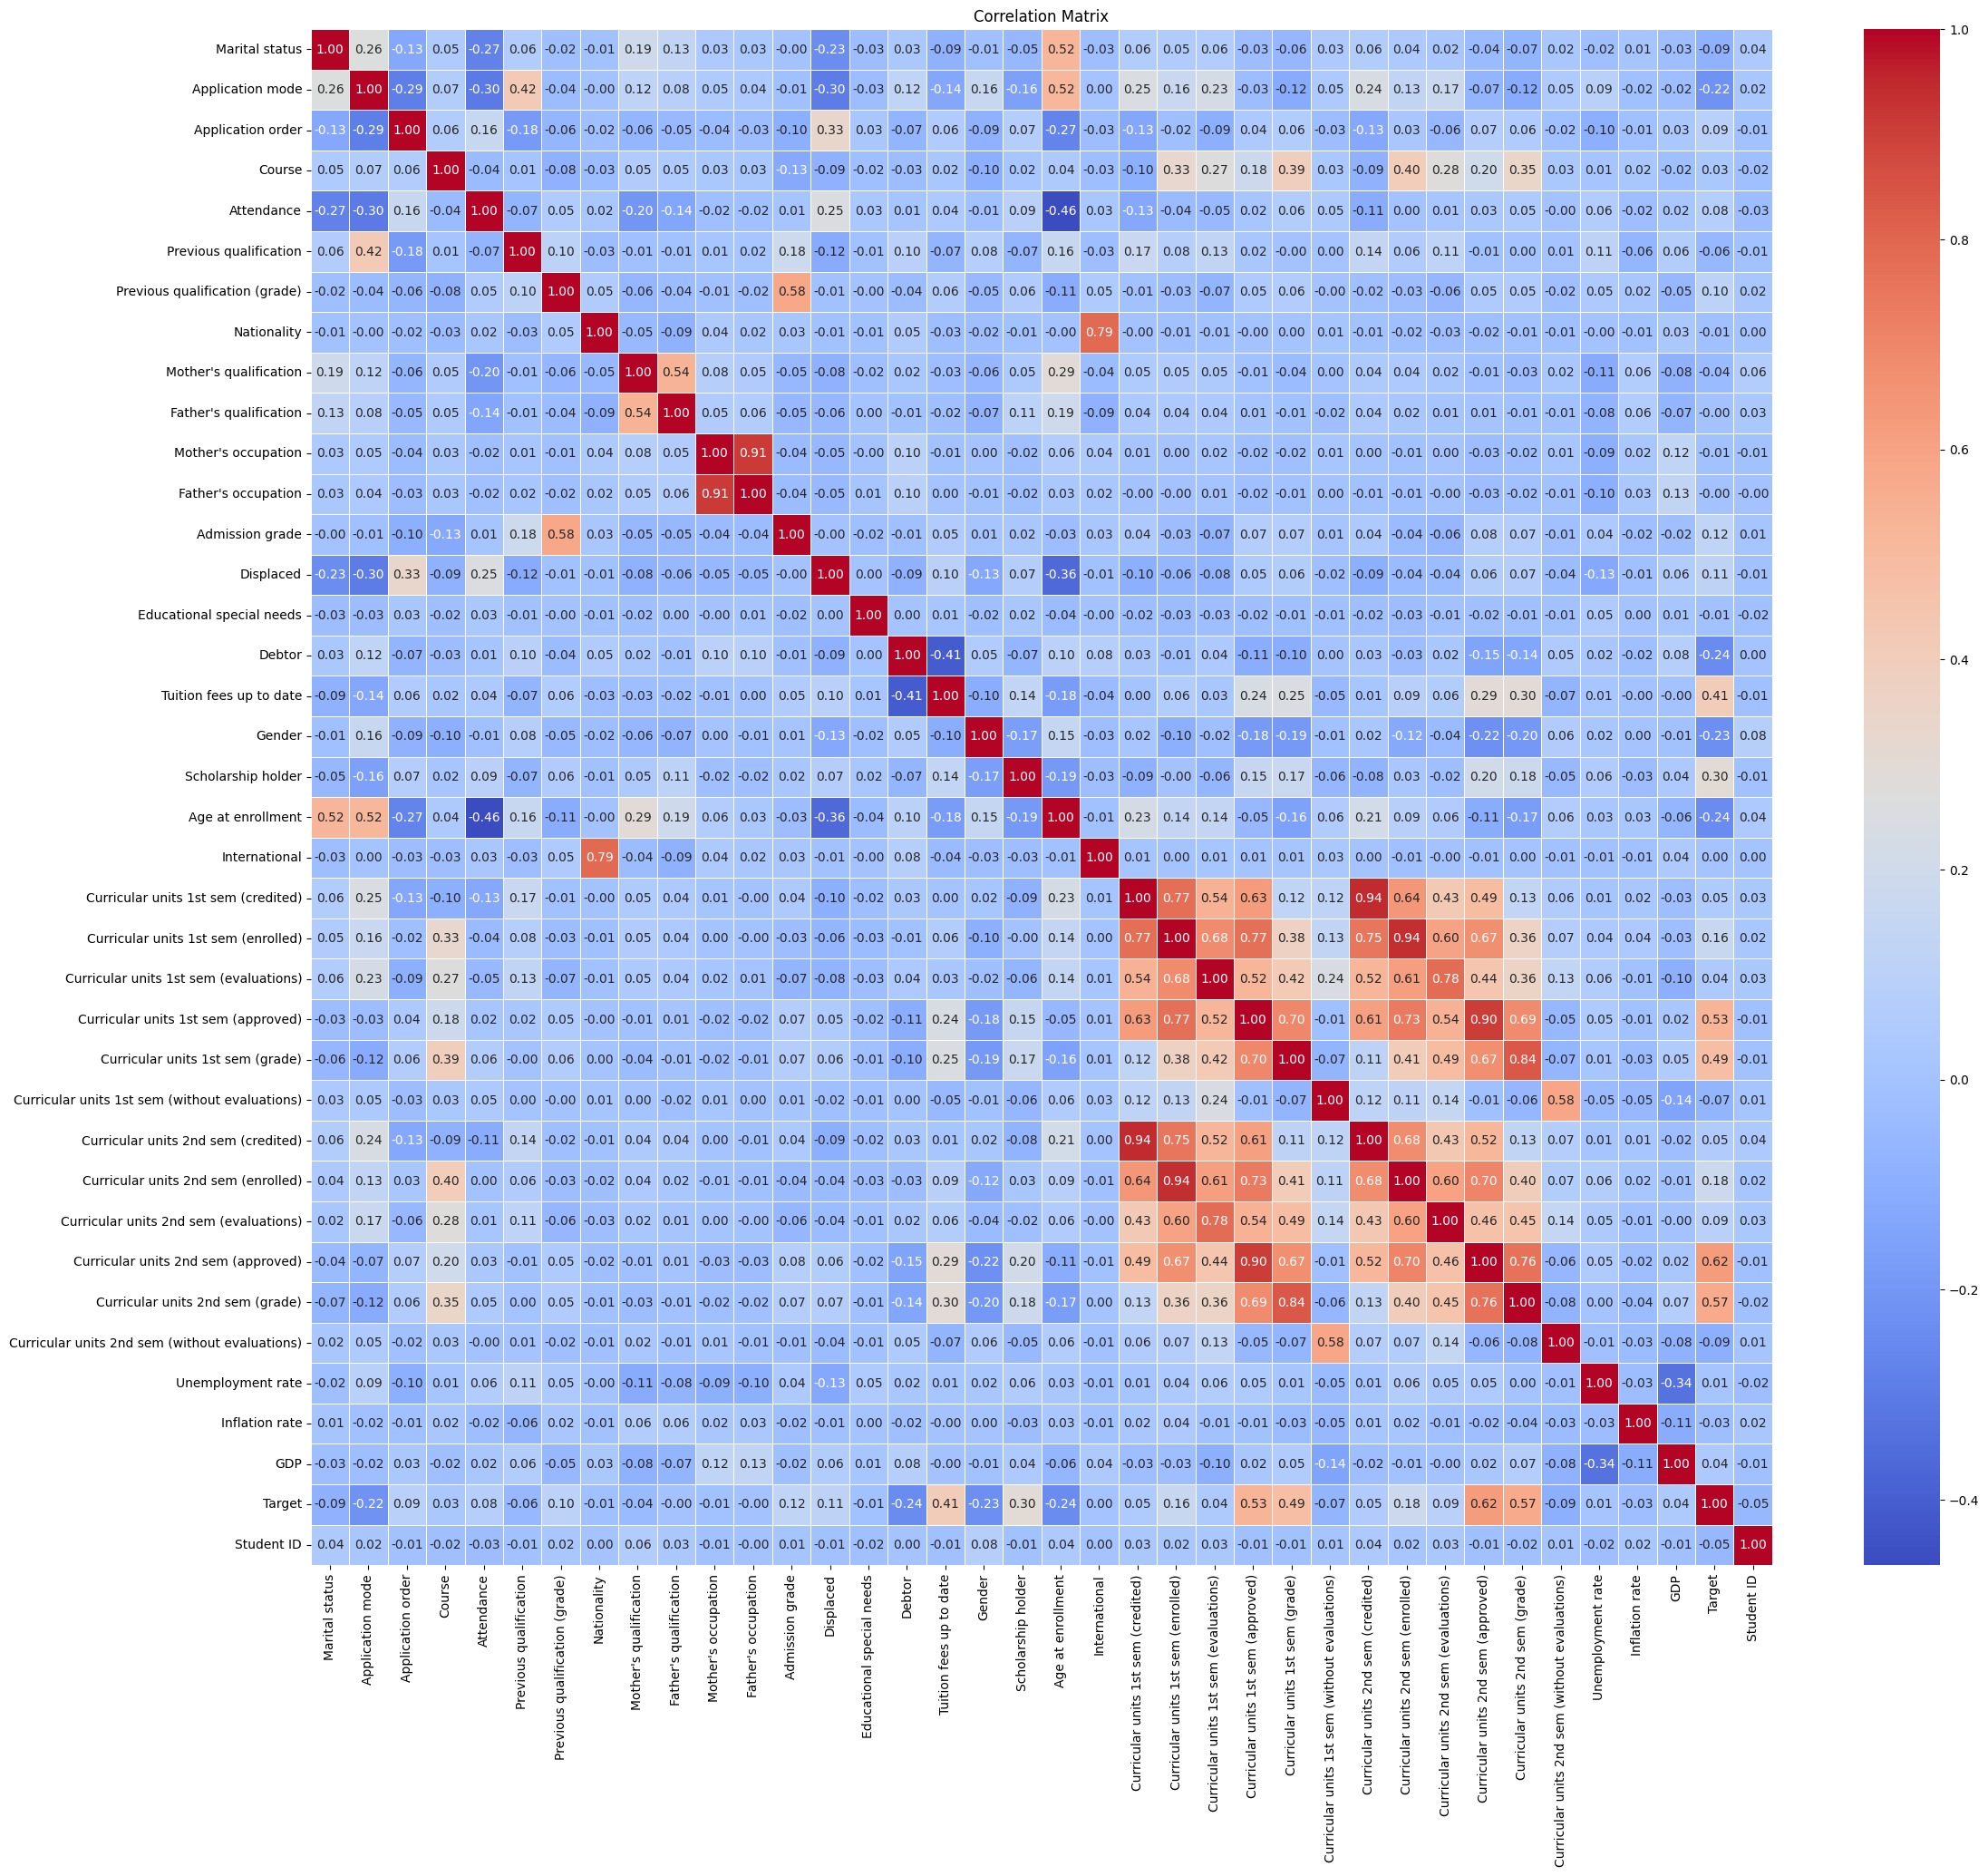

In [1138]:
# Cek korelasi keseluruhan
corr = df_with_id.corr(method='pearson')

plt.figure(figsize=(26, 22))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

#### Fokus ke fitur yang relevan

In [ ]:
# Kolom yang diabaikan
ignored_cols = [
    "Marital status", "Application mode", "Course",
    "Previous qualification", "Nationality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Student ID"
]

In [1142]:
relevant_df = df_with_id.drop(columns=ignored_cols)

relevant_df.head().T

,0,1,2,3,4
Application order,5.00,1.000000,5.00,2.000000,1.000000
Attendance,1.00,1.000000,1.00,1.000000,0.000000
Previous qualification (grade),122.00,160.000000,122.00,122.000000,100.000000
Admission grade,127.30,142.500000,124.80,119.600000,141.500000
Displaced,1.00,1.000000,1.00,1.000000,0.000000
Educational special needs,0.00,0.000000,0.00,0.000000,0.000000
Debtor,0.00,0.000000,0.00,0.000000,0.000000
Tuition fees up to date,1.00,0.000000,0.00,1.000000,1.000000
Gender,1.00,1.000000,1.00,0.000000,0.000000
Scholarship holder,0.00,0.000000,0.00,0.000000,0.000000


C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\3559940838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_plus.values, y=top_10_plus.index, palette='coolwarm', legend=False)


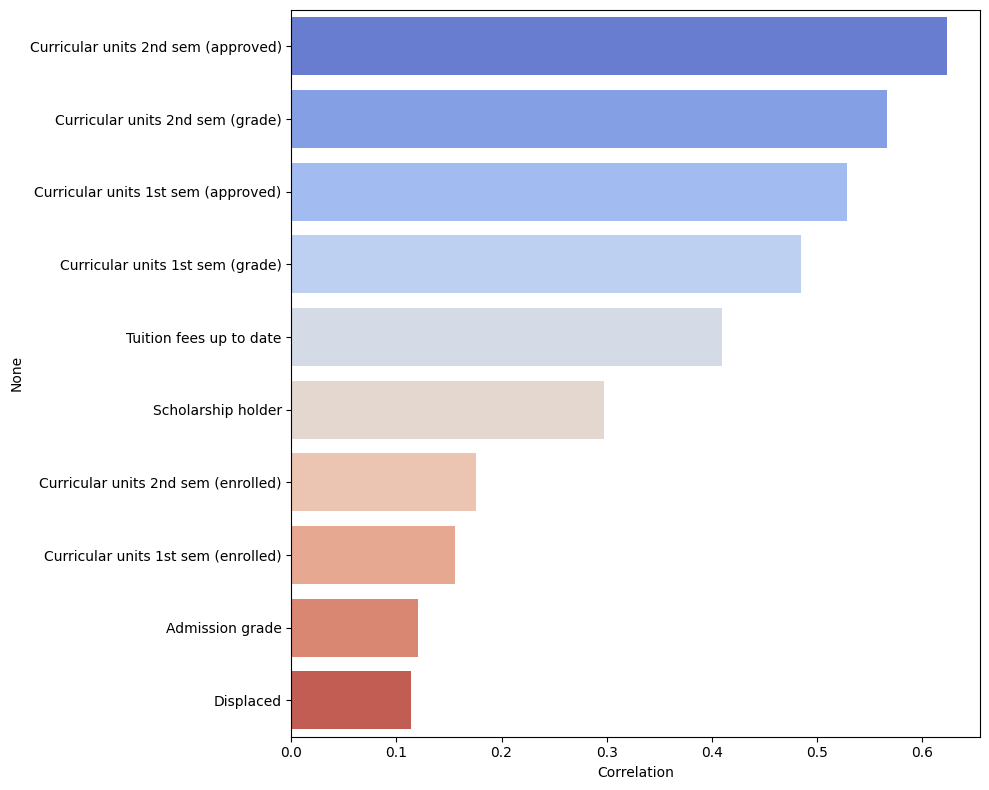

In [1143]:
# Cek Korelasi Positif terhadap Target
top_10_plus = relevant_df.corr(method='pearson')['Target'].drop('Target').sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_10_plus.values, y=top_10_plus.index, palette='coolwarm', legend=False)
plt.title('')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

_Insight_:
* Faktor-faktor yang berkorelasi positif terhadap status kelulusan mahasiswa saat ini didominasi oleh aspek capaian Akademik mahasiswa seperti jumlah SKS yang diambil tiap semester, jumlah SKS yang lulus di tiap semester, Nilai tiap semester, serta nilai penerimaan saat masuk. Selain itu, ada juga beberapa aspek non-akademik seperti kepatuhan pembayaran biaya pendidikan, status penerimaan beasiswa, serta lokasi tempat tinggal (kos atau tidak).
* Semakin besar jumlah SKS dan nilai yang diperoleh, maka probabilitas mahasiswa akan lulus semakin besar pula. 
* Jika mahasiswa disiplin dalam pembayaran tagian pendidikannya, maka probabilitas Dropoutnya akan rendah.
* Admission grade dapat menjadi indikator awal yang menunjukkan kemampuan akademik mahasiswa dalam menempuh pendidikan. Bila nilai admission grade tinggi, maka kemungkinan besar mahasiswa akan mampu memperoleh nilai semeseter yang tinggi juga. 

C:\Users\ACER\AppData\Local\Temp\ipykernel_11744\482373050.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_minus.values, y=top_10_minus.index, palette='coolwarm', legend=False)


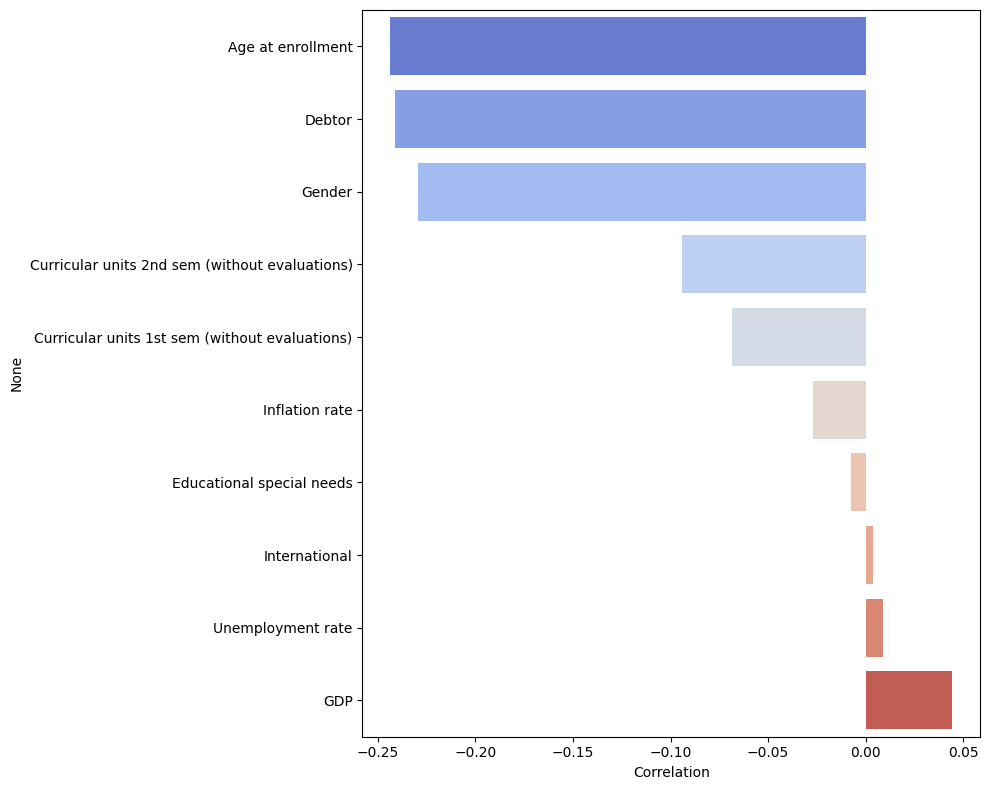

In [1144]:
# Cek Korelasi Negatif terhadap Target
top_10_minus = relevant_df.corr(method='pearson')['Target'].drop('Target').sort_values(ascending=True).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_10_minus.values, y=top_10_minus.index, palette='coolwarm', legend=False)
plt.title('')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

_Insight_:
* Faktor-faktor yang berkorelasi negatif cukup kuat terhadap status kelulusan mahasiswa dapat dijadikan indikator bahwa aspek-aspek tersebut memiliki pengaruh yang cukup kuat dan menjadi faktor pendorong mahasiswa dapat mengalami Dropout.
* Secara keseluruhan faktor-faktor tersebut dapat dikelompokkan menjadi aspek capaian akademik (Jumlah SKS yang gagal dinilai tiap semester), ekonomi (finansial dan makro), dan aspek sosial (usia, gender, kependudukan, dan kebutuhan khusus).

## Modeling

In [1147]:
model = Pipeline(steps=[
    ('encoder', encoder),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=4,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [1148]:
model.fit(X_train, y_train_encoded)

c:\Users\ACER\.conda\envs\data-science\lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('encoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe', OrdinalEncoder(),
                                                  ['Displaced',
                                                   'Educational special needs',
                                                   'Debtor',
                                                   'Tuition fees up to date',
                                                   'Scholarship holder']),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Attendance', 'Gender',
                                                   'International'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=4,
                                        min_samples_split=10, n_jobs=-1,
                                        random_state=42))])

## Evaluation

In [1150]:
y_pred = model.predict(X_test)
y_pred_label = y_le.inverse_transform(y_pred)

y_test_label = y_le.inverse_transform(y_test_encoded)
print(classification_report(y_test_label, y_pred_label))

              precision    recall  f1-score   support

     Dropout       0.90      0.84      0.87       255
    Graduate       0.90      0.94      0.92       399

    accuracy                           0.90       654
   macro avg       0.90      0.89      0.90       654
weighted avg       0.90      0.90      0.90       654



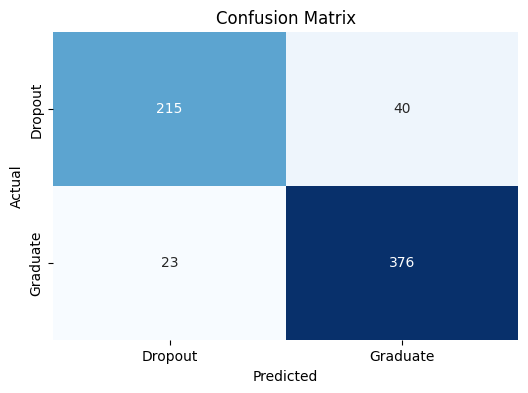

In [1158]:
# confusion matrix
cm = confusion_matrix(y_test_label, y_pred_label)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.xticks(ticks=np.arange(len(y_le.classes_)) + 0.5, labels=y_le.classes_)
plt.ylabel('Actual')
plt.yticks(ticks=np.arange(len(y_le.classes_)) + 0.5, labels=y_le.classes_)
plt.show()

In [1154]:
# feature importance
feature_importance_df = pd.DataFrame({
    'feature': x.columns,
    'importance': model.named_steps['classifier'].feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
20,Curricular units 2nd sem (approved),0.304625
14,Curricular units 1st sem (approved),0.169367
21,Curricular units 2nd sem (grade),0.151017
3,Displaced,0.072194
15,Curricular units 1st sem (grade),0.049415
10,International,0.031885
13,Curricular units 1st sem (evaluations),0.031609
19,Curricular units 2nd sem (evaluations),0.029275
4,Educational special needs,0.023909
12,Curricular units 1st sem (enrolled),0.019306


## Export

### Save Artifact

In [1159]:
# save model
artifacts = {
    'fitur_encoder': encoder,
    'label_encoder': y_le,
    'model': model,
    'feature_names': x.columns.tolist(),
    'target_classes': y_le.classes_.tolist()
}

joblib.dump(artifacts, 'student_dropout_model.pkl')

['student_dropout_model.pkl']

### Dataset for Dashboard

In [50]:
# save dashboard data
dashboard_df.to_csv('dashboard_data.csv', index=False)